# Kompleks Değerli Yapay Sinir Ağları (KDYSA) ile DNA-KODON- AMİNO ASİT Dizi Sınıflandırma
#### Açıklama: 
- Daha önce; İnsan vucuduna ait ve yaklaşık 500 ve üzeri protein çeşitliliği içeren Kinaz ve GPCR protein aileleri için UniProt uzantılı erişm (Acces) noları ile oluşturulan havuzdan herbir protein ailesi için basit rastgele örnekleme yöntemiyle (Simple Random Sampling) Train için 200 er örnek ve test için 100 er örnek seçilmiş; UniProt ve NCBI gen bankasından (Acces) numaralarıyla CDS-DNA (KODON) ve AMİNOASİT dizi formları fasta olarak indirilmiş; indirilen herbir dizi formuna ait örnekler, önerilen kompleks değerli yöntemler kullanılarak kompleks sayılara kodlanmış ve her bir dizi formu için excel dosyasına train (Train toplam: 400) ve test (Test toplam: 200) olarak kaydedilmiştir.
- Bu bölümde ise; kompleks değerlere dönüştürülmüş Kinaz ve GPCR proteinlerine ait DNA, KODON ve AMİNO ASİT dizileri Karmaşık Değerli Yapay Sinir Ağları (KDYSA) kullanılarak sınıflandırılmasktadır. 
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve Excel veri setinin 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılmaktadır.
- Sonuçlar grafiklerle görselleştirilmektedir.Ayrıca sonuçlar bir dosyada raporlanmaktadır. Farklı modelleri karşılaştırmak için sabit SPLIT_SEED = 42 tüm çalışmalarda aynı tutulmaya dikkat edilmiştir.  

### Çalışma Adımları:
#### 1- KDYSA ile DNA dizisi sınıflandırma
- KDYSA ile kompleks değerlere dönüştürülmüş DNA dizileri kullanılarak kinaz ve GPCR protein sınıflandırılması yapılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve Excel veri setinin 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılmaktadır.
#### 2- KDYSA ile KODON dizisi sınıflandırma
- KDYSA ile kompleks değerlere dönüştürülmüş KODON dizileri kullanılarak kinaz ve GPCR protein sınıflandırılması yapılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve Excel veri setinin 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılmaktadır.
#### 3- KDYSA  ile AMİNO ASİT dizi Sınıflandırma
- KDYSA ile kompleks değerlere dönüştürülmüş AMİNO ASİT dizileri kullanılarak kinaz ve GPCR protein sınıflandırılması yapılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve Excel veri setinin 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılmaktadır.

## 1) KDYSA ile kompleks değerli DNA dizisi sınıflandırma:
- Daha önce önerilen matematiksel yöntemlerle kompleks değerlere kodlanmış DNA dizilerine ait 400 train ve 200 test veri örneği kullanılarak kinaz (1) ve GPCR (0) protein aileleri KDYSA ile sınıflandırılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılır.
- Eğitim (train) ve Doğrulama (Val.) ve Son olarak Final Test için Accuracy oranları hesaplanmakta ve her iki sınıf için ayrı ayrı Precision/Recall/F1 hesaplanmaktadır.
- Sonuçlar grafiklerle görselleştirilir.

In [12]:
# =============================================================================
#  KOMPLEKS DEĞERLİ YAPAY SİNİR AĞLARI (KDYSA) - DNA SINIFLANDIRMA
#  L = 900   |   Veri kaynağı: cds_DNA_Compleks_L900.npz
# -----------------------------------------------------------------------------
# =============================================================================
# GEREKLİ KÜTÜPHANELER
# =============================================================================
from __future__ import annotations

import json
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from tensorflow.keras import Model, layers
from tensorflow.keras.optimizers import Adam

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")


# =============================================================================
#    SABİTLER
# =============================================================================
# .npz dosyasının tam yolu 
NPZ_YOLU          = r"C:\Users\matya\cds_DNA_Compleks_L900.npz"
CIKTI_DIZINI      = Path("./ciktilar_wirtinger_mlp_DNA_L900_npz")
CIKTI_DIZINI.mkdir(exist_ok=True)

L                 = 900
SINIF_SAYISI      = 2
SINIF_ADLARI      = {0: "GPCR", 1: "Kinase"}


GENLIK_NORMALIZASYONU = True

N_SPLITS          = 10
EPOCHS            = 200
BATCH_SIZE        = 10
OGRENME_ORANI     = 5e-4
WEIGHT_DECAY      = 1e-4

LAMBDA_CENTER_HEDEF     = 0.02
LAMBDA_CENTER_BASLANGIC = 0.0

LAMBDA_WARMUP_EPOCH     = 5

LABEL_SMOOTHING   = 0.02

NORON_SAYILARI    = (32, 16, 8)
DROPOUT_ORANLARI  = (0.30, 0.35, 0.35)


def yeni_run_seedi() -> int:
    return int(time.time() * 1000) % 10_000_000 + random.randint(0, 100_000)


RUN_SEED = yeni_run_seedi()
SPLIT_SEED = 42   #  karşılaştırma için sabit
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)

print(f"[INFO] Ana run seed       : {RUN_SEED}")
print(f"[INFO] Çıktı dizini       : {CIKTI_DIZINI.resolve()}")
print(f"[INFO] Veri kaynağı       : {NPZ_YOLU}")
print(f"[INFO] L (girdi uzunluğu) : {L}")
print(f"[INFO] Genlik norm. (X/L) : {GENLIK_NORMALIZASYONU}")
print(f"[INFO] λ_center hedef     : {LAMBDA_CENTER_HEDEF} (warmup: {LAMBDA_WARMUP_EPOCH} epoch)")
print(f"[INFO] Dropout            : {DROPOUT_ORANLARI}")
print(f"[INFO] ReduceLR monitor   : val_kayip_ce")
print(f"[INFO] EarlyStop monitor  : val_dogruluk (max)")


# =============================================================================
#    KOMPLEKS AKTİVASYONLAR
# =============================================================================
def komplex_tanh(z: tf.Tensor) -> tf.Tensor:
    return tf.complex(tf.math.tanh(tf.math.real(z)),
                      tf.math.tanh(tf.math.imag(z)))


class ModReLU(layers.Layer):
    """f(z) = ReLU(|z| + b) · (z / |z|)"""
    def __init__(self, eps: float = 1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        self.b = self.add_weight(shape=(int(input_shape[-1]),),
                                 initializer="zeros", trainable=True, name="b")

    def call(self, z):
        genlik  = tf.abs(z)
        katsayi = tf.nn.relu(genlik + self.b) / (genlik + self.eps)
        return tf.cast(katsayi, z.dtype) * z


# =============================================================================
#     KOMPLEKS NORMALİZASYON & DROPOUT
# =============================================================================
class KarmasikKatmanNorm(layers.Layer):
    def __init__(self, eps=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.gamma = self.add_weight(shape=(2, d), initializer="ones",
                                     trainable=True, name="gamma")
        self.beta  = self.add_weight(shape=(2, d), initializer="zeros",
                                     trainable=True, name="beta")

    def call(self, z):
        zr, zi = tf.math.real(z), tf.math.imag(z)
        x = tf.stack([zr, zi], axis=1)
        ort = tf.reduce_mean(x, axis=[1, 2], keepdims=True)
        var = tf.reduce_mean(tf.square(x - ort), axis=[1, 2], keepdims=True)
        x_hat = (x - ort) / tf.sqrt(var + self.eps)
        x_hat = x_hat * self.gamma[None, ...] + self.beta[None, ...]
        return tf.complex(x_hat[:, 0, :], x_hat[:, 1, :])


class KarmasikDropout(layers.Layer):
    def __init__(self, oran=0.2, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.oran = float(oran)
        self.seed = int(seed)
        self.rng  = None

    def build(self, input_shape):
        self.rng = tf.random.Generator.from_seed(self.seed)

    def call(self, z, training=False):
        if (not training) or self.oran <= 0.0:
            return z
        tutma = 1.0 - self.oran
        sekil = tf.shape(tf.math.real(z))
        maske = self.rng.uniform(sekil, dtype=tf.float32)
        maske = tf.cast(maske < tutma, tf.float32) / tutma
        maske = tf.cast(maske, z.dtype)
        return z * maske


# =============================================================================
#     KOMPLEKS YOĞUN KATMAN:
# =============================================================================
class KarmasikYogun(layers.Layer):
    def __init__(self, noron_sayisi, aktivasyon=None, l2=0.0, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.noron_sayisi = int(noron_sayisi)
        self.aktivasyon   = aktivasyon
        self.l2           = float(l2)
        self.seed         = int(seed)

    def build(self, input_shape):
        d    = int(input_shape[-1])
        init = tf.keras.initializers.GlorotUniform(seed=self.seed)
        k    = 1.0 / np.sqrt(2.0)

        def si(shape, dtype=None):
            return tf.cast(init(shape, dtype=dtype), tf.float32) * k

        reg = tf.keras.regularizers.L2(self.l2) if self.l2 > 0 else None

        self.wr = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wr")
        self.wi = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wi")
        self.br = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="br")
        self.bi = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="bi")

    def call(self, x):
        xr, xi = tf.math.real(x), tf.math.imag(x)
        yr = tf.matmul(xr, self.wr) - tf.matmul(xi, self.wi) + self.br
        yi = tf.matmul(xr, self.wi) + tf.matmul(xi, self.wr) + self.bi
        y  = tf.complex(yr, yi)
        return self.aktivasyon(y) if self.aktivasyon is not None else y


# =============================================================================
#     PROTOTİP ENERJİ BAŞLIĞI
# =============================================================================
class PrototipEnerjiBasligi(layers.Layer):
    def __init__(self, sinif_sayisi=2, prototip_ogrenilsin=True,
                 stddev=0.05, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.sinif_sayisi        = int(sinif_sayisi)
        self.prototip_ogrenilsin = bool(prototip_ogrenilsin)
        self.stddev              = float(stddev)
        self.seed                = int(seed)

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.prototip_real = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=self.stddev, seed=self.seed),
            trainable=self.prototip_ogrenilsin, name="prototip_real")
        self.prototip_imaj = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=self.stddev, seed=self.seed + 1),
            trainable=self.prototip_ogrenilsin, name="prototip_imaj")

    def call(self, z):
        zr = tf.expand_dims(tf.math.real(z), axis=1)
        zi = tf.expand_dims(tf.math.imag(z), axis=1)
        pr = tf.expand_dims(self.prototip_real, axis=0)
        pi = tf.expand_dims(self.prototip_imaj, axis=0)
        enerji = tf.reduce_sum((zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
        return -enerji, enerji


# =============================================================================
#     WIRTINGER CE - WIRTINGER CENTER LOSS
# =============================================================================
def wirtinger_ce_kaybi(logit, y_onehot, label_smoothing=0.0):
    y = tf.cast(y_onehot, tf.float32)
    if label_smoothing > 0.0:
        C = tf.cast(tf.shape(y)[-1], tf.float32)
        y = y * (1.0 - label_smoothing) + label_smoothing / C
    log_p = tf.nn.log_softmax(logit, axis=-1)
    return -tf.reduce_mean(tf.reduce_sum(y * log_p, axis=-1))


def wirtinger_center_kaybi(z, y_onehot, proto_real, proto_imaj):
    y  = tf.cast(y_onehot, tf.float32)
    pr = tf.matmul(y, proto_real)
    pi = tf.matmul(y, proto_imaj)
    zr = tf.math.real(z)
    zi = tf.math.imag(z)
    kare_mesafe = tf.reduce_sum(
        (zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
    return 0.5 * tf.reduce_mean(kare_mesafe)


# =============================================================================
#     EĞİTİM MODELİ
# =============================================================================
class KarmasikEgitici(Model):
    def __init__(self, kodlayici, baslik,
                 lambda_center_baslangic=0.0, label_smoothing=0.02):
        super().__init__()
        self.kodlayici       = kodlayici
        self.baslik          = baslik

        self.lambda_center   = tf.Variable(
            float(lambda_center_baslangic),
            trainable=False, dtype=tf.float32, name="lambda_center")

        self.label_smoothing = float(label_smoothing)
        self.acc             = tf.keras.metrics.CategoricalAccuracy(name="dogruluk")

    @property
    def metrics(self):
        return [self.acc]

    def call(self, x, training=False):
        z = self.kodlayici(x, training=training)
        logit, _ = self.baslik(z)
        return tf.nn.softmax(logit)

    def _kayip_hesapla(self, x_b, y_b, training=False):
        z = self.kodlayici(x_b, training=training)
        tf.debugging.assert_type(z, tf.complex64)
        logit, _ = self.baslik(z)
        prob = tf.nn.softmax(logit)

        kayip_ce = wirtinger_ce_kaybi(
            logit, y_b, label_smoothing=self.label_smoothing)

        kayip_center = wirtinger_center_kaybi(
            z, y_b,
            self.baslik.prototip_real,
            self.baslik.prototip_imaj)

        kayip_reg = tf.add_n(self.kodlayici.losses) \
                    if self.kodlayici.losses else 0.0

        toplam = kayip_ce + self.lambda_center * kayip_center + kayip_reg
        return toplam, kayip_ce, kayip_center, kayip_reg, prob

    def train_step(self, data):
        x_b, y_b = data
        with tf.GradientTape() as tape:
            toplam, kayip_ce, kayip_center, kayip_reg, prob = \
                self._kayip_hesapla(x_b, y_b, training=True)

        degiskenler = (self.kodlayici.trainable_variables
                       + self.baslik.trainable_variables)
        gradyanlar  = tape.gradient(toplam, degiskenler)
        gradyanlar  = [g if g is not None else tf.zeros_like(v)
                       for g, v in zip(gradyanlar, degiskenler)]
        gradyanlar, _ = tf.clip_by_global_norm(gradyanlar, 1.0)
        self.optimizer.apply_gradients(zip(gradyanlar, degiskenler))

        self.acc.update_state(y_b, prob)
        return {"kayip":         toplam,
                "kayip_ce":      kayip_ce,
                "kayip_center":  kayip_center,
                "kayip_reg":     kayip_reg,
                "lambda_center": self.lambda_center,
                "dogruluk":      self.acc.result()}

    def test_step(self, data):
        x_b, y_b = data
        toplam, kayip_ce, kayip_center, kayip_reg, prob = \
            self._kayip_hesapla(x_b, y_b, training=False)
        self.acc.update_state(y_b, prob)
        return {"kayip":         toplam,
                "kayip_ce":      kayip_ce,
                "kayip_center":  kayip_center,
                "kayip_reg":     kayip_reg,
                "lambda_center": self.lambda_center,
                "dogruluk":      self.acc.result()}


# =============================================================================
#     CALLBACKS
# =============================================================================
class PrototipIzleyiciCallback(tf.keras.callbacks.Callback):
    def __init__(self, kaydet_yolu: Path | None = None):
        super().__init__()
        self.tarih = []
        self.kaydet_yolu = kaydet_yolu

    def on_epoch_end(self, epoch, logs=None):
        pr = self.model.baslik.prototip_real.numpy()
        pi = self.model.baslik.prototip_imaj.numpy()
        ayrisma = float(np.sqrt(np.sum((pr[0] - pr[1]) ** 2
                                       + (pi[0] - pi[1]) ** 2)))
        self.tarih.append({"epoch": epoch, "p_ayrisma": ayrisma})
        if ayrisma < 1e-3:
            print(f"[UYARI] Epoch {epoch}: prototip ayrışması {ayrisma:.2e}")

    def on_train_end(self, logs=None):
        if self.kaydet_yolu is not None and len(self.tarih) > 0:
            pd.DataFrame(self.tarih).to_csv(self.kaydet_yolu, index=False)


# Lambda Center Scheduler
class LambdaCenterScheduler(tf.keras.callbacks.Callback):

    def __init__(self, baslangic=0.0, hedef=0.05, warmup_epoch=10, verbose=0):
        super().__init__()
        self.baslangic    = float(baslangic)
        self.hedef        = float(hedef)
        self.warmup_epoch = int(warmup_epoch)
        self.verbose      = int(verbose)

    def on_epoch_begin(self, epoch, logs=None):
        if self.warmup_epoch <= 0 or epoch >= self.warmup_epoch:
            yeni = self.hedef
        else:
            oran = epoch / self.warmup_epoch
            yeni = self.baslangic + (self.hedef - self.baslangic) * oran
        self.model.lambda_center.assign(yeni)
        if self.verbose:
            print(f"  [λ_center] Epoch {epoch}: {yeni:.4f}")


# =============================================================================
#     MODEL KURMA
# =============================================================================
def modeli_kur(L, seed,
               noronlar=NORON_SAYILARI,
               droplar=DROPOUT_ORANLARI,
               wd=WEIGHT_DECAY,
               lambda_baslangic=LAMBDA_CENTER_BASLANGIC,
               label_smoothing=LABEL_SMOOTHING,
               lr=OGRENME_ORANI) -> KarmasikEgitici:

    h1, h2, h3 = noronlar
    d1, d2, d3 = droplar

    giris = layers.Input(shape=(L,), dtype=tf.complex64, name="kompleks_giris")

    x = KarmasikYogun(h1, aktivasyon=None, l2=wd, seed=seed,
                      name="yogun_1")(giris)
    x = ModReLU(name="modrelu_1")(x)
    x = KarmasikKatmanNorm(name="norm_1")(x)
    x = KarmasikDropout(oran=d1, seed=seed, name="drop_1")(x)

    x = KarmasikYogun(h2, aktivasyon=komplex_tanh, l2=wd,
                      seed=seed + 1, name="yogun_2")(x)
    x = KarmasikKatmanNorm(name="norm_2")(x)
    x = KarmasikDropout(oran=d2, seed=seed + 1, name="drop_2")(x)

    z = KarmasikYogun(h3, aktivasyon=komplex_tanh, l2=wd,
                      seed=seed + 2, name="yogun_3")(x)
    z = KarmasikKatmanNorm(name="norm_3")(z)
    z = KarmasikDropout(oran=d3, seed=seed + 2, name="drop_3")(z)

    kodlayici = Model(giris, z, name="KarmasikMLPKodlayici")
    baslik    = PrototipEnerjiBasligi(sinif_sayisi=SINIF_SAYISI,
                                      seed=seed + 3, name="prototip_baslik")

    egitici = KarmasikEgitici(kodlayici=kodlayici, baslik=baslik,
                              lambda_center_baslangic=lambda_baslangic,
                              label_smoothing=label_smoothing)
    egitici.compile(optimizer=Adam(learning_rate=lr))
    egitici.build(input_shape=(None, L))
    return egitici


# =============================================================================
#    VERİ  —  .npz'den yükleme 
# =============================================================================
def veriyi_yukle_npz(npz_yolu, L, genlik_bol=True):


    d = np.load(npz_yolu, allow_pickle=False)

    def al(anahtar):
        if anahtar not in d.files:
            raise KeyError(
                f"'{anahtar}' anahtarı .npz içinde yok. "
                f"Mevcut anahtarlar: {list(d.files)}")
        return d[anahtar]

    X_tr = al("X_egitim").astype(np.complex64)
    X_te = al("X_test").astype(np.complex64)
    yi_tr = al("y_egitim").astype(int)
    yi_te = al("y_test").astype(int)

    # Şekil güvence kontrolü 
    assert X_tr.shape[1] == L, \
        f"Eğitim dizi uzunluğu {X_tr.shape[1]} != beklenen L={L}"
    assert X_te.shape[1] == L, \
        f"Test dizi uzunluğu {X_te.shape[1]} != beklenen L={L}"

    if genlik_bol:
        X_tr = (X_tr / np.complex64(L)).astype(np.complex64)
        X_te = (X_te / np.complex64(L)).astype(np.complex64)

    y_tr = tf.keras.utils.to_categorical(yi_tr, SINIF_SAYISI).astype(np.float32)
    y_te = tf.keras.utils.to_categorical(yi_te, SINIF_SAYISI).astype(np.float32)
    return X_tr, y_tr, yi_tr, X_te, y_te, yi_te


X_full_train, y_full_train, y_full_train_int, \
X_test,       y_test,       y_test_int = veriyi_yukle_npz(
    NPZ_YOLU, L=L, genlik_bol=GENLIK_NORMALIZASYONU)

print("\n" + "=" * 55)
print("  VERİ BİLGİSİ")
print("=" * 55)
print(f"CV havuzu   : {X_full_train.shape[0]} "
      f"(GPCR={np.sum(y_full_train_int == 0)}, "
      f"Kinase={np.sum(y_full_train_int == 1)})")
print(f"Final test  : {X_test.shape[0]} "
      f"(GPCR={np.sum(y_test_int == 0)}, "
      f"Kinase={np.sum(y_test_int == 1)})")
print(f"Girdi şekli : X_egitim {X_full_train.shape}  |  X_test {X_test.shape}")
print(f"|X| aralığı : [{np.abs(X_full_train).min():.4g}, "
      f"{np.abs(X_full_train).max():.4g}]  (genlik_bol={GENLIK_NORMALIZASYONU})")


# =============================================================================
#     CALLBACK   —  her fold için yenileniyor
# =============================================================================
def callback_listesi_olustur(kaydet_proto_csv: Path,
                             reduce_lr_monitor: str = "val_kayip_ce",   
                             early_stop_monitor: str = "val_dogruluk",
                             early_stop_mode: str = "max",
                             reduce_lr_patience: int = 10,
                             early_stop_patience: int = 25,
                             reduce_verbose: int = 0,
                             early_verbose: int = 0):
    return [
        #  Early stopping val_dogruluk üzerinden, mode=max
        tf.keras.callbacks.EarlyStopping(
            monitor=early_stop_monitor, mode=early_stop_mode,
            patience=early_stop_patience,
            restore_best_weights=True, verbose=early_verbose),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=reduce_lr_monitor, factor=0.5,
            patience=reduce_lr_patience, min_lr=1e-5,
            verbose=reduce_verbose),
        tf.keras.callbacks.TerminateOnNaN(),
        #  λ_center warmup scheduler
        LambdaCenterScheduler(
            baslangic=LAMBDA_CENTER_BASLANGIC,
            hedef=LAMBDA_CENTER_HEDEF,
            warmup_epoch=LAMBDA_WARMUP_EPOCH,
            verbose=0),
        PrototipIzleyiciCallback(kaydet_yolu=kaydet_proto_csv),
    ]


# =============================================================================
#    10-FOLD CV
# =============================================================================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)

fold_sonuclari = []

for fold_no, (tr_idx, vl_idx) in enumerate(
        skf.split(X_full_train, y_full_train_int), start=1):

    print(f"\n{'=' * 48}\n  FOLD {fold_no}/{N_SPLITS}\n{'=' * 48}")

    fold_seed = RUN_SEED + fold_no * 100
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(fold_seed)
    np.random.seed(fold_seed)
    random.seed(fold_seed)

    X_tr, X_vl = X_full_train[tr_idx], X_full_train[vl_idx]
    y_tr, y_vl = y_full_train[tr_idx], y_full_train[vl_idx]
    y_vl_int   = y_full_train_int[vl_idx]

    model = modeli_kur(L=L, seed=fold_seed)

    callbacks = callback_listesi_olustur(
        kaydet_proto_csv=CIKTI_DIZINI / f"fold_{fold_no:02d}_prototip_izleme.csv")

    history = model.fit(X_tr, y_tr, validation_data=(X_vl, y_vl),
                        epochs=EPOCHS, batch_size=BATCH_SIZE,
                        callbacks=callbacks, verbose=0)

    np.savez_compressed(
        CIKTI_DIZINI / f"fold_{fold_no:02d}_history.npz",
        **{k: np.array(v) for k, v in history.history.items()})

    y_vl_pred = np.argmax(model.predict(X_vl, verbose=0), axis=1)
    fold_acc  = accuracy_score(y_vl_int, y_vl_pred)

    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, labels=[0, 1], average=None, zero_division=0)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, average="macro", zero_division=0)

    h = history.history
    best_val_loss   = float(np.nanmin(h["val_kayip"]))
    best_val_acc    = float(np.nanmax(h["val_dogruluk"]))
    best_val_ce     = float(np.nanmin(h["val_kayip_ce"]))
    best_val_center = float(np.nanmin(h["val_kayip_center"]))

    fold_sonuclari.append({
        "fold": fold_no, "acc": fold_acc, "macro_f1": macro_f1,
        "macro_precision": prec_cls.mean(), "macro_recall": rec_cls.mean(),
        "gpcr_precision": prec_cls[0], "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0], "gpcr_support": sup_cls[0],
        "kinase_precision": prec_cls[1], "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1], "kinase_support": sup_cls[1],
        "best_val_loss":   best_val_loss,
        "best_val_acc":    best_val_acc,
        "best_val_ce":     best_val_ce,
        "best_val_center": best_val_center,
        "epoch_sayisi":    len(h["kayip"]),
    })

    print(f"Fold Acc       : {fold_acc:.4f}  |  Macro F1     : {macro_f1:.4f}")
    print(f"GPCR F1        : {f1_cls[0]:.4f}  |  Kinase F1    : {f1_cls[1]:.4f}")
    print(f"Best Val Acc   : {best_val_acc:.4f}  |  Best Val CE : {best_val_ce:.4f}")
    print(f"Epoch sayısı   : {fold_sonuclari[-1]['epoch_sayisi']}")


cv_df = pd.DataFrame(fold_sonuclari)

print("\n" + "=" * 55)
print("  10-FOLD CV ÖZET  (Wirtinger Hibrit MLP, npz)")
print("=" * 55)
print(cv_df[["fold", "acc", "macro_f1", "gpcr_f1", "kinase_f1",
             "best_val_acc", "best_val_ce",
             "epoch_sayisi"]].round(4).to_string(index=False))

print("\n--- CV ORTALAMA ± STD ---")
for k in ["acc", "macro_f1", "gpcr_f1", "kinase_f1",
          "best_val_loss", "best_val_acc",
          "best_val_ce", "best_val_center", "epoch_sayisi"]:
    print(f"  {k:22s}: {cv_df[k].mean():.4f} ± {cv_df[k].std(ddof=1):.4f}")

cv_df.to_excel(CIKTI_DIZINI / "cv_10_fold_npz.xlsx", index=False)


# =============================================================================
#     FİNAL MODEL
# =============================================================================
print("\n" + "=" * 55)
print("  FİNAL MODEL EĞİTİMİ  (Wirtinger Hibrit MLP, npz)")
print("=" * 55)

final_seed   = RUN_SEED + 9999
median_epoch = int(np.median(cv_df["epoch_sayisi"]))
print(f"[INFO] CV medyan epoch : {median_epoch}")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(final_seed)
np.random.seed(final_seed)
random.seed(final_seed)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10,
                             random_state=final_seed)
(final_tr_idx, final_vl_idx), = sss.split(X_full_train, y_full_train_int)
X_ftr, X_fvl = X_full_train[final_tr_idx], X_full_train[final_vl_idx]
y_ftr, y_fvl = y_full_train[final_tr_idx], y_full_train[final_vl_idx]

print(f"[INFO] Final train : {len(final_tr_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_tr_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_tr_idx] == 1)})")
print(f"[INFO] Final val   : {len(final_vl_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_vl_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_vl_idx] == 1)})")

final_model = modeli_kur(L=L, seed=final_seed)

final_callbacks = callback_listesi_olustur(
    kaydet_proto_csv     = CIKTI_DIZINI / "final_prototip_izleme.csv",
    reduce_lr_patience   = 8,
    early_stop_patience  = 25,
    reduce_verbose       = 1,
    early_verbose        = 1,
)

for cb in final_callbacks:
    if isinstance(cb, LambdaCenterScheduler):
        cb.verbose = 1

final_history = final_model.fit(
    X_ftr, y_ftr, validation_data=(X_fvl, y_fvl),
    epochs=median_epoch + 50,
    batch_size=BATCH_SIZE,
    shuffle=True, callbacks=final_callbacks, verbose=1)

np.savez_compressed(CIKTI_DIZINI / "final_history.npz",
                    **{k: np.array(v) for k, v in final_history.history.items()})


# =============================================================================
#     TEST DEĞERLENDİRME
# =============================================================================
test_eval = final_model.evaluate(X_test, y_test, verbose=0, return_dict=True)
y_test_prob = final_model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

test_cm  = confusion_matrix(y_test_int, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test_int, y_test_pred)

prec_t, rec_t, f1_t, sup_t = precision_recall_fscore_support(
    y_test_int, y_test_pred, labels=[0, 1], average=None, zero_division=0)
_, _, macro_f1_t, _ = precision_recall_fscore_support(
    y_test_int, y_test_pred, average="macro", zero_division=0)

print("\n" + "=" * 55)
print("  FİNAL TEST  (Wirtinger Hibrit MLP, npz)")
print("=" * 55)
print(f"Confusion Matrix:")
print(f"              pred_GPCR   pred_Kinase")
print(f"  true_GPCR     {test_cm[0, 0]:5d}       {test_cm[0, 1]:5d}")
print(f"  true_Kinase   {test_cm[1, 0]:5d}       {test_cm[1, 1]:5d}")
print()
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Test Loss (toplam)  : {test_eval['kayip']:.4f}")
print(f"Test Wirtinger CE   : {test_eval['kayip_ce']:.4f}")
print(f"Test Wirtinger Cnt  : {test_eval['kayip_center']:.4f}")
print(f"Test Macro F1       : {macro_f1_t:.4f}")
print(f"GPCR   F1/P/R       : {f1_t[0]:.4f}/{prec_t[0]:.4f}/{rec_t[0]:.4f}  (N={sup_t[0]})")
print(f"Kinase F1/P/R       : {f1_t[1]:.4f}/{prec_t[1]:.4f}/{rec_t[1]:.4f}  (N={sup_t[1]})")


# =============================================================================
#     KAYITLAR
# =============================================================================
final_model.save_weights(CIKTI_DIZINI / "final_model.weights.h5")

pd.DataFrame({
    "idx":          np.arange(len(y_test_int)),
    "y_true":       y_test_int,
    "y_true_label": [SINIF_ADLARI[i] for i in y_test_int],
    "y_pred":       y_test_pred,
    "y_pred_label": [SINIF_ADLARI[i] for i in y_test_pred],
    "prob_GPCR":    y_test_prob[:, 0],
    "prob_Kinase":  y_test_prob[:, 1],
}).to_csv(CIKTI_DIZINI / "test_tahminleri.csv", index=False)

meta = {
    "mimari":              "kompleks_mlp_wirtinger_hibrit_npz",
    "veri_kaynagi":        str(NPZ_YOLU),
    "genlik_normalizasyonu": (f"X / L (L={L})" if GENLIK_NORMALIZASYONU
                              else "yok (ilk katman batch-norm bekleniyor)"),
    "L":                   L,
    "kayip_formulasyonu":  "L = L_CE_wirtinger + lambda(t)*L_center_wirtinger + L2",
    "ayarlar":             {
        "lambda_hedef":      LAMBDA_CENTER_HEDEF,
        "warmup_epoch":      LAMBDA_WARMUP_EPOCH,
        "reduce_lr_monitor": "val_kayip_ce",
        "early_stop":        "val_dogruluk (mode=max)",
        "final_patience":    25,
        "dropout":           list(DROPOUT_ORANLARI),
        "scheduler":         "LambdaCenterScheduler (lineer warmup)",
    },
    "lambda_center_baslangic": LAMBDA_CENTER_BASLANGIC,
    "lambda_center_hedef":     LAMBDA_CENTER_HEDEF,
    "label_smoothing":         LABEL_SMOOTHING,
    "weight_decay":            WEIGHT_DECAY,
    "run_seed":                RUN_SEED,
    "final_seed":              final_seed,
    "n_splits":                N_SPLITS,
    "epochs_limit":            EPOCHS,
    "batch_size":              BATCH_SIZE,
    "lr":                      OGRENME_ORANI,
    "noron_sayilari":          list(NORON_SAYILARI),
    "cv_medyan_epoch":         int(median_epoch),
    "cv_acc_ortalama":         float(cv_df["acc"].mean()),
    "cv_acc_std":              float(cv_df["acc"].std(ddof=1)),
    "cv_macro_f1_ort":         float(cv_df["macro_f1"].mean()),
    "cv_macro_f1_std":         float(cv_df["macro_f1"].std(ddof=1)),
    "test_acc":                float(test_acc),
    "test_macro_f1":           float(macro_f1_t),
    "test_loss":               float(test_eval["kayip"]),
    "test_loss_ce":            float(test_eval["kayip_ce"]),
    "test_loss_center":        float(test_eval["kayip_center"]),
    "tensorflow":              tf.__version__,
    "numpy":                   np.__version__,
}
with open(CIKTI_DIZINI / "deney_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print(f"\n[INFO] Tüm kayıtlar: {CIKTI_DIZINI.resolve()}")

[INFO] Ana run seed       : 3216284
[INFO] Çıktı dizini       : C:\Users\matya\ciktilar_wirtinger_mlp_DNA_L900_npz
[INFO] Veri kaynağı       : C:\Users\matya\cds_DNA_Compleks_L900.npz
[INFO] L (girdi uzunluğu) : 900
[INFO] Genlik norm. (X/L) : True
[INFO] λ_center hedef     : 0.02 (warmup: 5 epoch)
[INFO] Dropout            : (0.3, 0.35, 0.35)
[INFO] ReduceLR monitor   : val_kayip_ce
[INFO] EarlyStop monitor  : val_dogruluk (max)

  VERİ BİLGİSİ
CV havuzu   : 400 (GPCR=200, Kinase=200)
Final test  : 200 (GPCR=100, Kinase=100)
Girdi şekli : X_egitim (400, 900)  |  X_test (200, 900)
|X| aralığı : [0.001111, 1]  (genlik_bol=True)

  FOLD 1/10
Fold Acc       : 0.9250  |  Macro F1     : 0.9250
GPCR F1        : 0.9268  |  Kinase F1    : 0.9231
Best Val Acc   : 0.9250  |  Best Val CE : 0.3281
Epoch sayısı   : 32

  FOLD 2/10
Fold Acc       : 0.9250  |  Macro F1     : 0.9250
GPCR F1        : 0.9231  |  Kinase F1    : 0.9268
Best Val Acc   : 0.9250  |  Best Val CE : 0.0729
Epoch sayısı   : 44



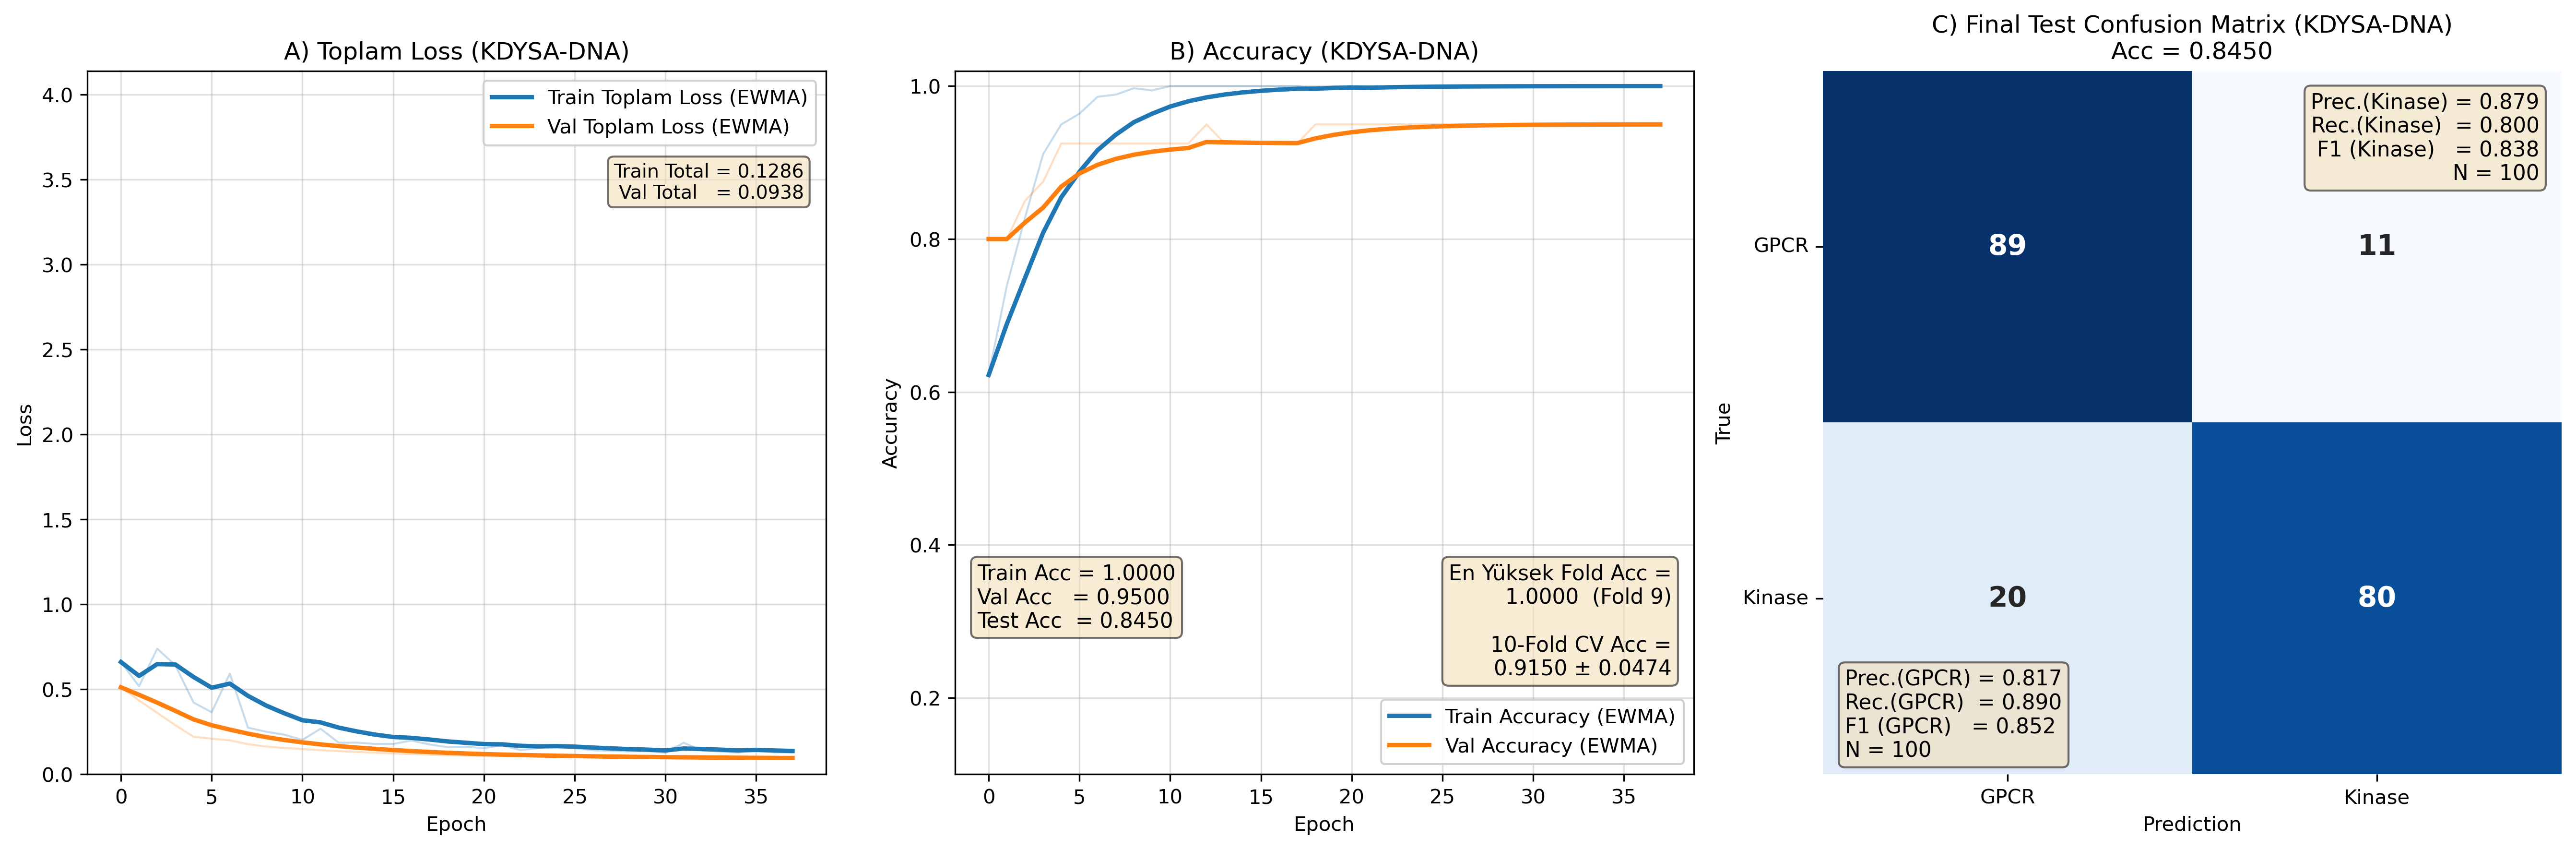

In [13]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME —  KDYSA DNA SINIFLANDIRMA
#
#   Panel A : Toplam Wirtinger Kayıp
#   Panel B : Accuracy (EWMA yumuşatmalı)
#   Panel C : Confusion Matris
#
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, f1_score


# -------------------------------------------------------------------------
# 1-  History anahtarları
# -------------------------------------------------------------------------
LOSS_KEY       = "kayip"
VAL_LOSS_KEY   = "val_kayip"
CE_KEY         = "kayip_ce"
VAL_CE_KEY     = "val_kayip_ce"
CENTER_KEY     = "kayip_center"
VAL_CENTER_KEY = "val_kayip_center"
ACC_KEY        = "dogruluk"
VAL_ACC_KEY    = "val_dogruluk"


# -------------------------------------------------------------------------
# 2-  EWMA yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return pd.Series(np.asarray(dizi, dtype=float)) \
             .ewm(alpha=alpha, adjust=True).mean().values


h = final_history.history
train_loss_ham = np.asarray(h[LOSS_KEY],     dtype=float)
val_loss_ham   = np.asarray(h[VAL_LOSS_KEY], dtype=float)
train_acc_ham  = np.asarray(h[ACC_KEY],      dtype=float)
val_acc_ham    = np.asarray(h[VAL_ACC_KEY],  dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)


# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son = float(train_loss_ham[-1])
val_loss_son   = float(val_loss_ham[-1])
train_acc_son  = float(train_acc_ham[-1])
val_acc_son    = float(val_acc_ham[-1])

train_ce_son     = float(h[CE_KEY][-1])         if CE_KEY         in h else np.nan
val_ce_son       = float(h[VAL_CE_KEY][-1])     if VAL_CE_KEY     in h else np.nan
train_center_son = float(h[CENTER_KEY][-1])     if CENTER_KEY     in h else np.nan
val_center_son   = float(h[VAL_CENTER_KEY][-1]) if VAL_CENTER_KEY in h else np.nan


# -------------------------------------------------------------------------
# 4-  Test sınıf metrikleri
# -------------------------------------------------------------------------
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test_int, y_test_pred,
    labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_test_int, y_test_pred,
                         average="macro", zero_division=0)


# -------------------------------------------------------------------------
# 5.  CV özet
# -------------------------------------------------------------------------
cv_acc_mean           = cv_df["acc"].mean()
cv_acc_std            = cv_df["acc"].std(ddof=1)
cv_best_val_loss_mean = cv_df["best_val_loss"].mean()
cv_best_val_loss_std  = cv_df["best_val_loss"].std(ddof=1)
cv_best_val_acc_mean  = cv_df["best_val_acc"].mean()
cv_best_val_acc_std   = cv_df["best_val_acc"].std(ddof=1)
cv_macro_f1_mean      = cv_df["macro_f1"].mean()
cv_macro_f1_std       = cv_df["macro_f1"].std(ddof=1)
en_yuksek_fold_acc    = cv_df["acc"].max()
en_yuksek_fold_no     = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])



# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

# ── Panel A: sadece toplam loss + en yüksek fold loss ────────────────────
text_loss = "\n".join((
    f"Train Total = {train_loss_son:.4f}",
    f"Val Total   = {val_loss_son:.4f}",
))

#  Panel B kutu 1: Train / Val / Test acc
text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {test_acc:.4f}",
))

#  Panel B kutu 2: fold istatistikleri
text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

#  Panel C: sınıf kutuları
text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))

text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))


# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN = "#1f77b4"
C_VAL   = "#ff7f0e"

# ==========================================================================
#  A) Toplam Wirtinger Kayıp
# ==========================================================================
ax[0].plot(train_loss_ham, color=C_TRAIN, linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[0].plot(val_loss_ham,   color=C_VAL,   linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[0].plot(train_loss_sm,  color=C_TRAIN, linewidth=2.2,
           label="Train Toplam Loss (EWMA)")
ax[0].plot(val_loss_sm,    color=C_VAL,   linewidth=2.2,
           label="Val Toplam Loss (EWMA)")

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9)
ax[0].set_title("A) Toplam Loss (KDYSA-DNA)")

ymax_loss = max(np.max(train_loss_ham), np.max(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 5.60))

# Tek kutu: Train/Val Total + en düşük fold loss
ax[0].text(0.97, 0.87, text_loss,
           transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.5, bbox=props)

# ==========================================================================
#  B) Accuracy
# ==========================================================================
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2,
           label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2,
           label="Val Accuracy (EWMA)")

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title("B) Accuracy (KDYSA-DNA)")
ax[1].set_ylim(0.1, 1.02)

#  Kutu 1: Train / Val / Test Acc
ax[1].text(0.03, 0.30, text_acc_1,
           transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)

#  Kutu 2: fold istatistikleri
ax[1].text(0.97, 0.30, text_acc_2,
           transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

# ==========================================================================
#  C) Confusion Matrix
# ==========================================================================
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
            cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})

ax[2].set_xlabel("Prediction")
ax[2].set_ylabel("True")
ax[2].set_title(
    f"C) Final Test Confusion Matrix (KDYSA-DNA)\nAcc = {test_acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]])
ax[2].set_yticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]], rotation=0)

ax[2].text(0.03, 0.15, text_gpcr,
           transform=ax[2].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase,
           transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

plt.tight_layout()
plt.savefig(f"wirtinger_hibrit_mlp_L{L}_gorsellestirme.png",
            dpi=600, bbox_inches="tight")
plt.show()

## 2) KDYSA ile kompleks değerli KODON dizisi sınıflandırma:
- Daha önce önerilen matematiksel yöntemlerle kompleks değerlere kodlanmış KODON dizilerine ait 400 train ve 200 test veri örneği kullanılarak kinaz (1) ve GPCR (0) protein aileleri KDYSA ile sınıflandırılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılır.
- Eğitim (train) ve Doğrulama (Val.) ve Son olarak Final Test için Accuracy oranları hesaplanmakta ve her iki sınıf için ayrı ayrı Precision/Recall/F1 hesaplanmaktadır.
- Sonuçlar grafiklerle görselleştirilir.

In [15]:
# =============================================================================
#  KOMPLEKS DEĞERLİ YAPAY SİNİR AĞLARI (KDYSA) - KODON SINIFLANDIRMA
#  L = 300  (300 kodon)      Veri kaynağı: cds_KODON_Compleks_L900.npz
# -----------------------------------------------------------------------------
# =============================================================================
# GEREKLİ KÜTÜPHANELER
# =============================================================================
from __future__ import annotations

import json
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from tensorflow.keras import Model, layers
from tensorflow.keras.optimizers import Adam

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")


# =============================================================================
#    SABİTLER
# =============================================================================
# .npz dosyasının tam yolu 
NPZ_YOLU          = r"C:\Users\matya\cds_KODON_Compleks_L900.npz"
CIKTI_DIZINI      = Path("./ciktilar_wirtinger_mlp_kodon_L300_npz")
CIKTI_DIZINI.mkdir(exist_ok=True)

L                 = 300   
SINIF_SAYISI      = 2
SINIF_ADLARI      = {0: "GPCR", 1: "Kinase"}

GENLIK_NORMALIZASYONU = True

N_SPLITS          = 10
EPOCHS            = 200
BATCH_SIZE        = 10
OGRENME_ORANI     = 5e-4
WEIGHT_DECAY      = 1e-4

LAMBDA_CENTER_HEDEF     = 0.02
LAMBDA_CENTER_BASLANGIC = 0.0

LAMBDA_WARMUP_EPOCH     = 5

LABEL_SMOOTHING   = 0.02

NORON_SAYILARI    = (32, 16, 8)
DROPOUT_ORANLARI  = (0.30, 0.35, 0.35)


def yeni_run_seedi() -> int:
    return int(time.time() * 1000) % 10_000_000 + random.randint(0, 100_000)


RUN_SEED = yeni_run_seedi()
SPLIT_SEED = 42   
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)

print(f"[INFO] Ana run seed       : {RUN_SEED}")
print(f"[INFO] Çıktı dizini       : {CIKTI_DIZINI.resolve()}")
print(f"[INFO] Veri kaynağı       : {NPZ_YOLU}")
print(f"[INFO] L (kodon sayısı)   : {L}")
print(f"[INFO] Genlik norm. (X/L) : {GENLIK_NORMALIZASYONU}")
print(f"[INFO] λ_center hedef     : {LAMBDA_CENTER_HEDEF} (warmup: {LAMBDA_WARMUP_EPOCH} epoch)")
print(f"[INFO] Dropout            : {DROPOUT_ORANLARI}")
print(f"[INFO] ReduceLR monitor   : val_kayip_ce")
print(f"[INFO] EarlyStop monitor  : val_dogruluk (max)")


# =============================================================================
#    KOMPLEKS AKTİVASYONLAR
# =============================================================================
def komplex_tanh(z: tf.Tensor) -> tf.Tensor:
    return tf.complex(tf.math.tanh(tf.math.real(z)),
                      tf.math.tanh(tf.math.imag(z)))


class ModReLU(layers.Layer):
    """f(z) = ReLU(|z| + b) · (z / |z|)"""
    def __init__(self, eps: float = 1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        self.b = self.add_weight(shape=(int(input_shape[-1]),),
                                 initializer="zeros", trainable=True, name="b")

    def call(self, z):
        genlik  = tf.abs(z)
        katsayi = tf.nn.relu(genlik + self.b) / (genlik + self.eps)
        return tf.cast(katsayi, z.dtype) * z


# =============================================================================
#     KOMPLEKS NORMALİZASYON & DROPOUT
# =============================================================================
class KarmasikKatmanNorm(layers.Layer):
    def __init__(self, eps=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.gamma = self.add_weight(shape=(2, d), initializer="ones",
                                     trainable=True, name="gamma")
        self.beta  = self.add_weight(shape=(2, d), initializer="zeros",
                                     trainable=True, name="beta")

    def call(self, z):
        zr, zi = tf.math.real(z), tf.math.imag(z)
        x = tf.stack([zr, zi], axis=1)
        ort = tf.reduce_mean(x, axis=[1, 2], keepdims=True)
        var = tf.reduce_mean(tf.square(x - ort), axis=[1, 2], keepdims=True)
        x_hat = (x - ort) / tf.sqrt(var + self.eps)
        x_hat = x_hat * self.gamma[None, ...] + self.beta[None, ...]
        return tf.complex(x_hat[:, 0, :], x_hat[:, 1, :])


class KarmasikDropout(layers.Layer):
    def __init__(self, oran=0.2, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.oran = float(oran)
        self.seed = int(seed)
        self.rng  = None

    def build(self, input_shape):
        self.rng = tf.random.Generator.from_seed(self.seed)

    def call(self, z, training=False):
        if (not training) or self.oran <= 0.0:
            return z
        tutma = 1.0 - self.oran
        sekil = tf.shape(tf.math.real(z))
        maske = self.rng.uniform(sekil, dtype=tf.float32)
        maske = tf.cast(maske < tutma, tf.float32) / tutma
        maske = tf.cast(maske, z.dtype)
        return z * maske


# =============================================================================
#     KOMPLEKS YOĞUN KATMAN:
# =============================================================================
class KarmasikYogun(layers.Layer):
    def __init__(self, noron_sayisi, aktivasyon=None, l2=0.0, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.noron_sayisi = int(noron_sayisi)
        self.aktivasyon   = aktivasyon
        self.l2           = float(l2)
        self.seed         = int(seed)

    def build(self, input_shape):
        d    = int(input_shape[-1])
        init = tf.keras.initializers.GlorotUniform(seed=self.seed)
        k    = 1.0 / np.sqrt(2.0)

        def si(shape, dtype=None):
            return tf.cast(init(shape, dtype=dtype), tf.float32) * k

        reg = tf.keras.regularizers.L2(self.l2) if self.l2 > 0 else None

        self.wr = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wr")
        self.wi = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wi")
        self.br = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="br")
        self.bi = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="bi")

    def call(self, x):
        xr, xi = tf.math.real(x), tf.math.imag(x)
        yr = tf.matmul(xr, self.wr) - tf.matmul(xi, self.wi) + self.br
        yi = tf.matmul(xr, self.wi) + tf.matmul(xi, self.wr) + self.bi
        y  = tf.complex(yr, yi)
        return self.aktivasyon(y) if self.aktivasyon is not None else y


# =============================================================================
#     PROTOTİP ENERJİ BAŞLIĞI
# =============================================================================
class PrototipEnerjiBasligi(layers.Layer):
    def __init__(self, sinif_sayisi=2, prototip_ogrenilsin=True,
                 stddev=0.05, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.sinif_sayisi        = int(sinif_sayisi)
        self.prototip_ogrenilsin = bool(prototip_ogrenilsin)
        self.stddev              = float(stddev)
        self.seed                = int(seed)

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.prototip_real = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=self.stddev, seed=self.seed),
            trainable=self.prototip_ogrenilsin, name="prototip_real")
        self.prototip_imaj = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=self.stddev, seed=self.seed + 1),
            trainable=self.prototip_ogrenilsin, name="prototip_imaj")

    def call(self, z):
        zr = tf.expand_dims(tf.math.real(z), axis=1)
        zi = tf.expand_dims(tf.math.imag(z), axis=1)
        pr = tf.expand_dims(self.prototip_real, axis=0)
        pi = tf.expand_dims(self.prototip_imaj, axis=0)
        enerji = tf.reduce_sum((zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
        return -enerji, enerji


# =============================================================================
#     WIRTINGER CE & WIRTINGER CENTER LOSS
# =============================================================================
def wirtinger_ce_kaybi(logit, y_onehot, label_smoothing=0.0):
    y = tf.cast(y_onehot, tf.float32)
    if label_smoothing > 0.0:
        C = tf.cast(tf.shape(y)[-1], tf.float32)
        y = y * (1.0 - label_smoothing) + label_smoothing / C
    log_p = tf.nn.log_softmax(logit, axis=-1)
    return -tf.reduce_mean(tf.reduce_sum(y * log_p, axis=-1))


def wirtinger_center_kaybi(z, y_onehot, proto_real, proto_imaj):
    y  = tf.cast(y_onehot, tf.float32)
    pr = tf.matmul(y, proto_real)
    pi = tf.matmul(y, proto_imaj)
    zr = tf.math.real(z)
    zi = tf.math.imag(z)
    kare_mesafe = tf.reduce_sum(
        (zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
    return 0.5 * tf.reduce_mean(kare_mesafe)


# =============================================================================
#     EĞİTİCİ MODEL
# =============================================================================
class KarmasikEgitici(Model):
    def __init__(self, kodlayici, baslik,
                 lambda_center_baslangic=0.0, label_smoothing=0.02):
        super().__init__()
        self.kodlayici       = kodlayici
        self.baslik          = baslik

        self.lambda_center   = tf.Variable(
            float(lambda_center_baslangic),
            trainable=False, dtype=tf.float32, name="lambda_center")

        self.label_smoothing = float(label_smoothing)
        self.acc             = tf.keras.metrics.CategoricalAccuracy(name="dogruluk")

    @property
    def metrics(self):
        return [self.acc]

    def call(self, x, training=False):
        z = self.kodlayici(x, training=training)
        logit, _ = self.baslik(z)
        return tf.nn.softmax(logit)

    def _kayip_hesapla(self, x_b, y_b, training=False):
        z = self.kodlayici(x_b, training=training)
        tf.debugging.assert_type(z, tf.complex64)
        logit, _ = self.baslik(z)
        prob = tf.nn.softmax(logit)

        kayip_ce = wirtinger_ce_kaybi(
            logit, y_b, label_smoothing=self.label_smoothing)

        kayip_center = wirtinger_center_kaybi(
            z, y_b,
            self.baslik.prototip_real,
            self.baslik.prototip_imaj)

        kayip_reg = tf.add_n(self.kodlayici.losses) \
                    if self.kodlayici.losses else 0.0

        toplam = kayip_ce + self.lambda_center * kayip_center + kayip_reg
        return toplam, kayip_ce, kayip_center, kayip_reg, prob

    def train_step(self, data):
        x_b, y_b = data
        with tf.GradientTape() as tape:
            toplam, kayip_ce, kayip_center, kayip_reg, prob = \
                self._kayip_hesapla(x_b, y_b, training=True)

        degiskenler = (self.kodlayici.trainable_variables
                       + self.baslik.trainable_variables)
        gradyanlar  = tape.gradient(toplam, degiskenler)
        gradyanlar  = [g if g is not None else tf.zeros_like(v)
                       for g, v in zip(gradyanlar, degiskenler)]
        gradyanlar, _ = tf.clip_by_global_norm(gradyanlar, 1.0)
        self.optimizer.apply_gradients(zip(gradyanlar, degiskenler))

        self.acc.update_state(y_b, prob)
        return {"kayip":         toplam,
                "kayip_ce":      kayip_ce,
                "kayip_center":  kayip_center,
                "kayip_reg":     kayip_reg,
                "lambda_center": self.lambda_center,
                "dogruluk":      self.acc.result()}

    def test_step(self, data):
        x_b, y_b = data
        toplam, kayip_ce, kayip_center, kayip_reg, prob = \
            self._kayip_hesapla(x_b, y_b, training=False)
        self.acc.update_state(y_b, prob)
        return {"kayip":         toplam,
                "kayip_ce":      kayip_ce,
                "kayip_center":  kayip_center,
                "kayip_reg":     kayip_reg,
                "lambda_center": self.lambda_center,
                "dogruluk":      self.acc.result()}


# =============================================================================
#     CALLBACKS
# =============================================================================
class PrototipIzleyiciCallback(tf.keras.callbacks.Callback):
    def __init__(self, kaydet_yolu: Path | None = None):
        super().__init__()
        self.tarih = []
        self.kaydet_yolu = kaydet_yolu

    def on_epoch_end(self, epoch, logs=None):
        pr = self.model.baslik.prototip_real.numpy()
        pi = self.model.baslik.prototip_imaj.numpy()
        ayrisma = float(np.sqrt(np.sum((pr[0] - pr[1]) ** 2
                                       + (pi[0] - pi[1]) ** 2)))
        self.tarih.append({"epoch": epoch, "p_ayrisma": ayrisma})
        if ayrisma < 1e-3:
            print(f"[UYARI] Epoch {epoch}: prototip ayrışması {ayrisma:.2e}")

    def on_train_end(self, logs=None):
        if self.kaydet_yolu is not None and len(self.tarih) > 0:
            pd.DataFrame(self.tarih).to_csv(self.kaydet_yolu, index=False)


# Lambda Center Scheduler
class LambdaCenterScheduler(tf.keras.callbacks.Callback):

    def __init__(self, baslangic=0.0, hedef=0.05, warmup_epoch=10, verbose=0):
        super().__init__()
        self.baslangic    = float(baslangic)
        self.hedef        = float(hedef)
        self.warmup_epoch = int(warmup_epoch)
        self.verbose      = int(verbose)

    def on_epoch_begin(self, epoch, logs=None):
        if self.warmup_epoch <= 0 or epoch >= self.warmup_epoch:
            yeni = self.hedef
        else:
            oran = epoch / self.warmup_epoch
            yeni = self.baslangic + (self.hedef - self.baslangic) * oran
        self.model.lambda_center.assign(yeni)
        if self.verbose:
            print(f"  [λ_center] Epoch {epoch}: {yeni:.4f}")


# =============================================================================
#     MODEL KURMA
# =============================================================================
def modeli_kur(L, seed,
               noronlar=NORON_SAYILARI,
               droplar=DROPOUT_ORANLARI,
               wd=WEIGHT_DECAY,
               lambda_baslangic=LAMBDA_CENTER_BASLANGIC,
               label_smoothing=LABEL_SMOOTHING,
               lr=OGRENME_ORANI) -> KarmasikEgitici:

    h1, h2, h3 = noronlar
    d1, d2, d3 = droplar

    giris = layers.Input(shape=(L,), dtype=tf.complex64, name="kompleks_giris")

    x = KarmasikYogun(h1, aktivasyon=None, l2=wd, seed=seed,
                      name="yogun_1")(giris)
    x = ModReLU(name="modrelu_1")(x)
    x = KarmasikKatmanNorm(name="norm_1")(x)
    x = KarmasikDropout(oran=d1, seed=seed, name="drop_1")(x)

    x = KarmasikYogun(h2, aktivasyon=komplex_tanh, l2=wd,
                      seed=seed + 1, name="yogun_2")(x)
    x = KarmasikKatmanNorm(name="norm_2")(x)
    x = KarmasikDropout(oran=d2, seed=seed + 1, name="drop_2")(x)

    z = KarmasikYogun(h3, aktivasyon=komplex_tanh, l2=wd,
                      seed=seed + 2, name="yogun_3")(x)
    z = KarmasikKatmanNorm(name="norm_3")(z)
    z = KarmasikDropout(oran=d3, seed=seed + 2, name="drop_3")(z)

    kodlayici = Model(giris, z, name="KarmasikMLPKodlayici")
    baslik    = PrototipEnerjiBasligi(sinif_sayisi=SINIF_SAYISI,
                                      seed=seed + 3, name="prototip_baslik")

    egitici = KarmasikEgitici(kodlayici=kodlayici, baslik=baslik,
                              lambda_center_baslangic=lambda_baslangic,
                              label_smoothing=label_smoothing)
    egitici.compile(optimizer=Adam(learning_rate=lr))
    egitici.build(input_shape=(None, L))
    return egitici


# =============================================================================
#    VERİ  —  .npz'den yükleme 
# =============================================================================
def veriyi_yukle_npz(npz_yolu, L, genlik_bol=True):

    d = np.load(npz_yolu, allow_pickle=False)

    def al(anahtar):
        if anahtar not in d.files:
            raise KeyError(
                f"'{anahtar}' anahtarı .npz içinde yok. "
                f"Mevcut anahtarlar: {list(d.files)}")
        return d[anahtar]

    X_tr = al("X_egitim").astype(np.complex64)
    X_te = al("X_test").astype(np.complex64)
    yi_tr = al("y_egitim").astype(int)
    yi_te = al("y_test").astype(int)

    # Şekil güvence kontrolü (dolgusuz sabit uzunluk her dizi tam 300 kodon)
    assert X_tr.shape[1] == L, \
        f"Eğitim kodon sayısı {X_tr.shape[1]} != beklenen L={L}"
    assert X_te.shape[1] == L, \
        f"Test kodon sayısı {X_te.shape[1]} != beklenen L={L}"

    if genlik_bol:
        X_tr = (X_tr / np.complex64(L)).astype(np.complex64)
        X_te = (X_te / np.complex64(L)).astype(np.complex64)

    y_tr = tf.keras.utils.to_categorical(yi_tr, SINIF_SAYISI).astype(np.float32)
    y_te = tf.keras.utils.to_categorical(yi_te, SINIF_SAYISI).astype(np.float32)
    return X_tr, y_tr, yi_tr, X_te, y_te, yi_te


X_full_train, y_full_train, y_full_train_int, \
X_test,       y_test,       y_test_int = veriyi_yukle_npz(
    NPZ_YOLU, L=L, genlik_bol=GENLIK_NORMALIZASYONU)

print("\n" + "=" * 55)
print("  VERİ BİLGİSİ")
print("=" * 55)
print(f"CV havuzu   : {X_full_train.shape[0]} "
      f"(GPCR={np.sum(y_full_train_int == 0)}, "
      f"Kinase={np.sum(y_full_train_int == 1)})")
print(f"Final test  : {X_test.shape[0]} "
      f"(GPCR={np.sum(y_test_int == 0)}, "
      f"Kinase={np.sum(y_test_int == 1)})")
print(f"Girdi şekli : X_egitim {X_full_train.shape}  |  X_test {X_test.shape}")
print(f"|X| aralığı : [{np.abs(X_full_train).min():.4g}, "
      f"{np.abs(X_full_train).max():.4g}]  (genlik_bol={GENLIK_NORMALIZASYONU})")


# =============================================================================
#     CALLBACK   —  her fold için yenileniyor
# =============================================================================
def callback_listesi_olustur(kaydet_proto_csv: Path,
                             reduce_lr_monitor: str = "val_kayip_ce",   
                             early_stop_monitor: str = "val_dogruluk",
                             early_stop_mode: str = "max",
                             reduce_lr_patience: int = 10,
                             early_stop_patience: int = 25,
                             reduce_verbose: int = 0,
                             early_verbose: int = 0):
    return [
        #  Early stopping val_dogruluk üzerinden, mode=max
        tf.keras.callbacks.EarlyStopping(
            monitor=early_stop_monitor, mode=early_stop_mode,
            patience=early_stop_patience,
            restore_best_weights=True, verbose=early_verbose),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=reduce_lr_monitor, factor=0.5,
            patience=reduce_lr_patience, min_lr=1e-5,
            verbose=reduce_verbose),
        tf.keras.callbacks.TerminateOnNaN(),
        #  λ_center warmup scheduler
        LambdaCenterScheduler(
            baslangic=LAMBDA_CENTER_BASLANGIC,
            hedef=LAMBDA_CENTER_HEDEF,
            warmup_epoch=LAMBDA_WARMUP_EPOCH,
            verbose=0),
        PrototipIzleyiciCallback(kaydet_yolu=kaydet_proto_csv),
    ]


# =============================================================================
#    10-FOLD CV
# =============================================================================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)

fold_sonuclari = []

for fold_no, (tr_idx, vl_idx) in enumerate(
        skf.split(X_full_train, y_full_train_int), start=1):

    print(f"\n{'=' * 48}\n  FOLD {fold_no}/{N_SPLITS}\n{'=' * 48}")

    fold_seed = RUN_SEED + fold_no * 100
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(fold_seed)
    np.random.seed(fold_seed)
    random.seed(fold_seed)

    X_tr, X_vl = X_full_train[tr_idx], X_full_train[vl_idx]
    y_tr, y_vl = y_full_train[tr_idx], y_full_train[vl_idx]
    y_vl_int   = y_full_train_int[vl_idx]

    model = modeli_kur(L=L, seed=fold_seed)

    callbacks = callback_listesi_olustur(
        kaydet_proto_csv=CIKTI_DIZINI / f"fold_{fold_no:02d}_prototip_izleme.csv")

    history = model.fit(X_tr, y_tr, validation_data=(X_vl, y_vl),
                        epochs=EPOCHS, batch_size=BATCH_SIZE,
                        callbacks=callbacks, verbose=0)

    np.savez_compressed(
        CIKTI_DIZINI / f"fold_{fold_no:02d}_history.npz",
        **{k: np.array(v) for k, v in history.history.items()})

    y_vl_pred = np.argmax(model.predict(X_vl, verbose=0), axis=1)
    fold_acc  = accuracy_score(y_vl_int, y_vl_pred)

    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, labels=[0, 1], average=None, zero_division=0)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, average="macro", zero_division=0)

    h = history.history
    best_val_loss   = float(np.nanmin(h["val_kayip"]))
    best_val_acc    = float(np.nanmax(h["val_dogruluk"]))
    best_val_ce     = float(np.nanmin(h["val_kayip_ce"]))
    best_val_center = float(np.nanmin(h["val_kayip_center"]))

    fold_sonuclari.append({
        "fold": fold_no, "acc": fold_acc, "macro_f1": macro_f1,
        "macro_precision": prec_cls.mean(), "macro_recall": rec_cls.mean(),
        "gpcr_precision": prec_cls[0], "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0], "gpcr_support": sup_cls[0],
        "kinase_precision": prec_cls[1], "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1], "kinase_support": sup_cls[1],
        "best_val_loss":   best_val_loss,
        "best_val_acc":    best_val_acc,
        "best_val_ce":     best_val_ce,
        "best_val_center": best_val_center,
        "epoch_sayisi":    len(h["kayip"]),
    })

    print(f"Fold Acc       : {fold_acc:.4f}  |  Macro F1     : {macro_f1:.4f}")
    print(f"GPCR F1        : {f1_cls[0]:.4f}  |  Kinase F1    : {f1_cls[1]:.4f}")
    print(f"Best Val Acc   : {best_val_acc:.4f}  |  Best Val CE : {best_val_ce:.4f}")
    print(f"Epoch sayısı   : {fold_sonuclari[-1]['epoch_sayisi']}")


cv_df = pd.DataFrame(fold_sonuclari)

print("\n" + "=" * 55)
print("  10-FOLD CV ÖZET  (Wirtinger Hibrit MLP, kodon npz)")
print("=" * 55)
print(cv_df[["fold", "acc", "macro_f1", "gpcr_f1", "kinase_f1",
             "best_val_acc", "best_val_ce",
             "epoch_sayisi"]].round(4).to_string(index=False))

print("\n--- CV ORTALAMA ± STD ---")
for k in ["acc", "macro_f1", "gpcr_f1", "kinase_f1",
          "best_val_loss", "best_val_acc",
          "best_val_ce", "best_val_center", "epoch_sayisi"]:
    print(f"  {k:22s}: {cv_df[k].mean():.4f} ± {cv_df[k].std(ddof=1):.4f}")

cv_df.to_excel(CIKTI_DIZINI / "cv_10_fold_npz.xlsx", index=False)


# =============================================================================
#     FİNAL MODEL
# =============================================================================
print("\n" + "=" * 55)
print("  FİNAL MODEL EĞİTİMİ  (Wirtinger Hibrit MLP, kodon npz)")
print("=" * 55)

final_seed   = RUN_SEED + 9999
median_epoch = int(np.median(cv_df["epoch_sayisi"]))
print(f"[INFO] CV medyan epoch : {median_epoch}")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(final_seed)
np.random.seed(final_seed)
random.seed(final_seed)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10,
                             random_state=final_seed)
(final_tr_idx, final_vl_idx), = sss.split(X_full_train, y_full_train_int)
X_ftr, X_fvl = X_full_train[final_tr_idx], X_full_train[final_vl_idx]
y_ftr, y_fvl = y_full_train[final_tr_idx], y_full_train[final_vl_idx]

print(f"[INFO] Final train : {len(final_tr_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_tr_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_tr_idx] == 1)})")
print(f"[INFO] Final val   : {len(final_vl_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_vl_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_vl_idx] == 1)})")

final_model = modeli_kur(L=L, seed=final_seed)

final_callbacks = callback_listesi_olustur(
    kaydet_proto_csv     = CIKTI_DIZINI / "final_prototip_izleme.csv",
    reduce_lr_patience   = 8,
    early_stop_patience  = 25,
    reduce_verbose       = 1,
    early_verbose        = 1,
)

for cb in final_callbacks:
    if isinstance(cb, LambdaCenterScheduler):
        cb.verbose = 1

final_history = final_model.fit(
    X_ftr, y_ftr, validation_data=(X_fvl, y_fvl),
    epochs=median_epoch + 50,
    batch_size=BATCH_SIZE,
    shuffle=True, callbacks=final_callbacks, verbose=1)

np.savez_compressed(CIKTI_DIZINI / "final_history.npz",
                    **{k: np.array(v) for k, v in final_history.history.items()})


# =============================================================================
#     TEST DEĞERLENDİRME
# =============================================================================
test_eval = final_model.evaluate(X_test, y_test, verbose=0, return_dict=True)
y_test_prob = final_model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

test_cm  = confusion_matrix(y_test_int, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test_int, y_test_pred)

prec_t, rec_t, f1_t, sup_t = precision_recall_fscore_support(
    y_test_int, y_test_pred, labels=[0, 1], average=None, zero_division=0)
_, _, macro_f1_t, _ = precision_recall_fscore_support(
    y_test_int, y_test_pred, average="macro", zero_division=0)

print("\n" + "=" * 55)
print("  FİNAL TEST  (Wirtinger Hibrit MLP, kodon npz)")
print("=" * 55)
print(f"Confusion Matrix:")
print(f"              pred_GPCR   pred_Kinase")
print(f"  true_GPCR     {test_cm[0, 0]:5d}       {test_cm[0, 1]:5d}")
print(f"  true_Kinase   {test_cm[1, 0]:5d}       {test_cm[1, 1]:5d}")
print()
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Test Loss (toplam)  : {test_eval['kayip']:.4f}")
print(f"Test Wirtinger CE   : {test_eval['kayip_ce']:.4f}")
print(f"Test Wirtinger Cnt  : {test_eval['kayip_center']:.4f}")
print(f"Test Macro F1       : {macro_f1_t:.4f}")
print(f"GPCR   F1/P/R       : {f1_t[0]:.4f}/{prec_t[0]:.4f}/{rec_t[0]:.4f}  (N={sup_t[0]})")
print(f"Kinase F1/P/R       : {f1_t[1]:.4f}/{prec_t[1]:.4f}/{rec_t[1]:.4f}  (N={sup_t[1]})")


# =============================================================================
#     KAYITLAR
# =============================================================================
final_model.save_weights(CIKTI_DIZINI / "final_model.weights.h5")

pd.DataFrame({
    "idx":          np.arange(len(y_test_int)),
    "y_true":       y_test_int,
    "y_true_label": [SINIF_ADLARI[i] for i in y_test_int],
    "y_pred":       y_test_pred,
    "y_pred_label": [SINIF_ADLARI[i] for i in y_test_pred],
    "prob_GPCR":    y_test_prob[:, 0],
    "prob_Kinase":  y_test_prob[:, 1],
}).to_csv(CIKTI_DIZINI / "test_tahminleri.csv", index=False)

meta = {
    "mimari":              "kompleks_mlp_wirtinger_hibrit_kodon_npz",
    "veri_kaynagi":        str(NPZ_YOLU),
    "temsil":              "kodon (300 kodon)",
    "genlik_normalizasyonu": (f"X / L (L={L})" if GENLIK_NORMALIZASYONU
                              else "yok (ilk katman batch-norm bekleniyor)"),
    "L":                   L,
    "kayip_formulasyonu":  "L = L_CE_wirtinger + lambda(t)*L_center_wirtinger + L2",
    "ayarlar":             {
        "lambda_hedef":      LAMBDA_CENTER_HEDEF,
        "warmup_epoch":      LAMBDA_WARMUP_EPOCH,
        "reduce_lr_monitor": "val_kayip_ce",
        "early_stop":        "val_dogruluk (mode=max)",
        "final_patience":    25,
        "dropout":           list(DROPOUT_ORANLARI),
        "scheduler":         "LambdaCenterScheduler (lineer warmup)",
    },
    "lambda_center_baslangic": LAMBDA_CENTER_BASLANGIC,
    "lambda_center_hedef":     LAMBDA_CENTER_HEDEF,
    "label_smoothing":         LABEL_SMOOTHING,
    "weight_decay":            WEIGHT_DECAY,
    "run_seed":                RUN_SEED,
    "final_seed":              final_seed,
    "n_splits":                N_SPLITS,
    "epochs_limit":            EPOCHS,
    "batch_size":              BATCH_SIZE,
    "lr":                      OGRENME_ORANI,
    "noron_sayilari":          list(NORON_SAYILARI),
    "cv_medyan_epoch":         int(median_epoch),
    "cv_acc_ortalama":         float(cv_df["acc"].mean()),
    "cv_acc_std":              float(cv_df["acc"].std(ddof=1)),
    "cv_macro_f1_ort":         float(cv_df["macro_f1"].mean()),
    "cv_macro_f1_std":         float(cv_df["macro_f1"].std(ddof=1)),
    "test_acc":                float(test_acc),
    "test_macro_f1":           float(macro_f1_t),
    "test_loss":               float(test_eval["kayip"]),
    "test_loss_ce":            float(test_eval["kayip_ce"]),
    "test_loss_center":        float(test_eval["kayip_center"]),
    "tensorflow":              tf.__version__,
    "numpy":                   np.__version__,
}
with open(CIKTI_DIZINI / "deney_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print(f"\n[INFO] Tüm kayıtlar: {CIKTI_DIZINI.resolve()}")

[INFO] Ana run seed       : 4203947
[INFO] Çıktı dizini       : C:\Users\matya\ciktilar_wirtinger_mlp_kodon_L300_npz
[INFO] Veri kaynağı       : C:\Users\matya\cds_KODON_Compleks_L900.npz
[INFO] L (kodon sayısı)   : 300
[INFO] Genlik norm. (X/L) : True
[INFO] λ_center hedef     : 0.02 (warmup: 5 epoch)
[INFO] Dropout            : (0.3, 0.35, 0.35)
[INFO] ReduceLR monitor   : val_kayip_ce
[INFO] EarlyStop monitor  : val_dogruluk (max)

  VERİ BİLGİSİ
CV havuzu   : 400 (GPCR=200, Kinase=200)
Final test  : 200 (GPCR=100, Kinase=100)
Girdi şekli : X_egitim (400, 300)  |  X_test (200, 300)
|X| aralığı : [0.003333, 1]  (genlik_bol=True)

  FOLD 1/10
Fold Acc       : 0.8250  |  Macro F1     : 0.8249
GPCR F1        : 0.8293  |  Kinase F1    : 0.8205
Best Val Acc   : 0.8250  |  Best Val CE : 0.5256
Epoch sayısı   : 48

  FOLD 2/10
Fold Acc       : 0.8250  |  Macro F1     : 0.8249
GPCR F1        : 0.8205  |  Kinase F1    : 0.8293
Best Val Acc   : 0.8250  |  Best Val CE : 0.5717
Epoch sayısı   : 

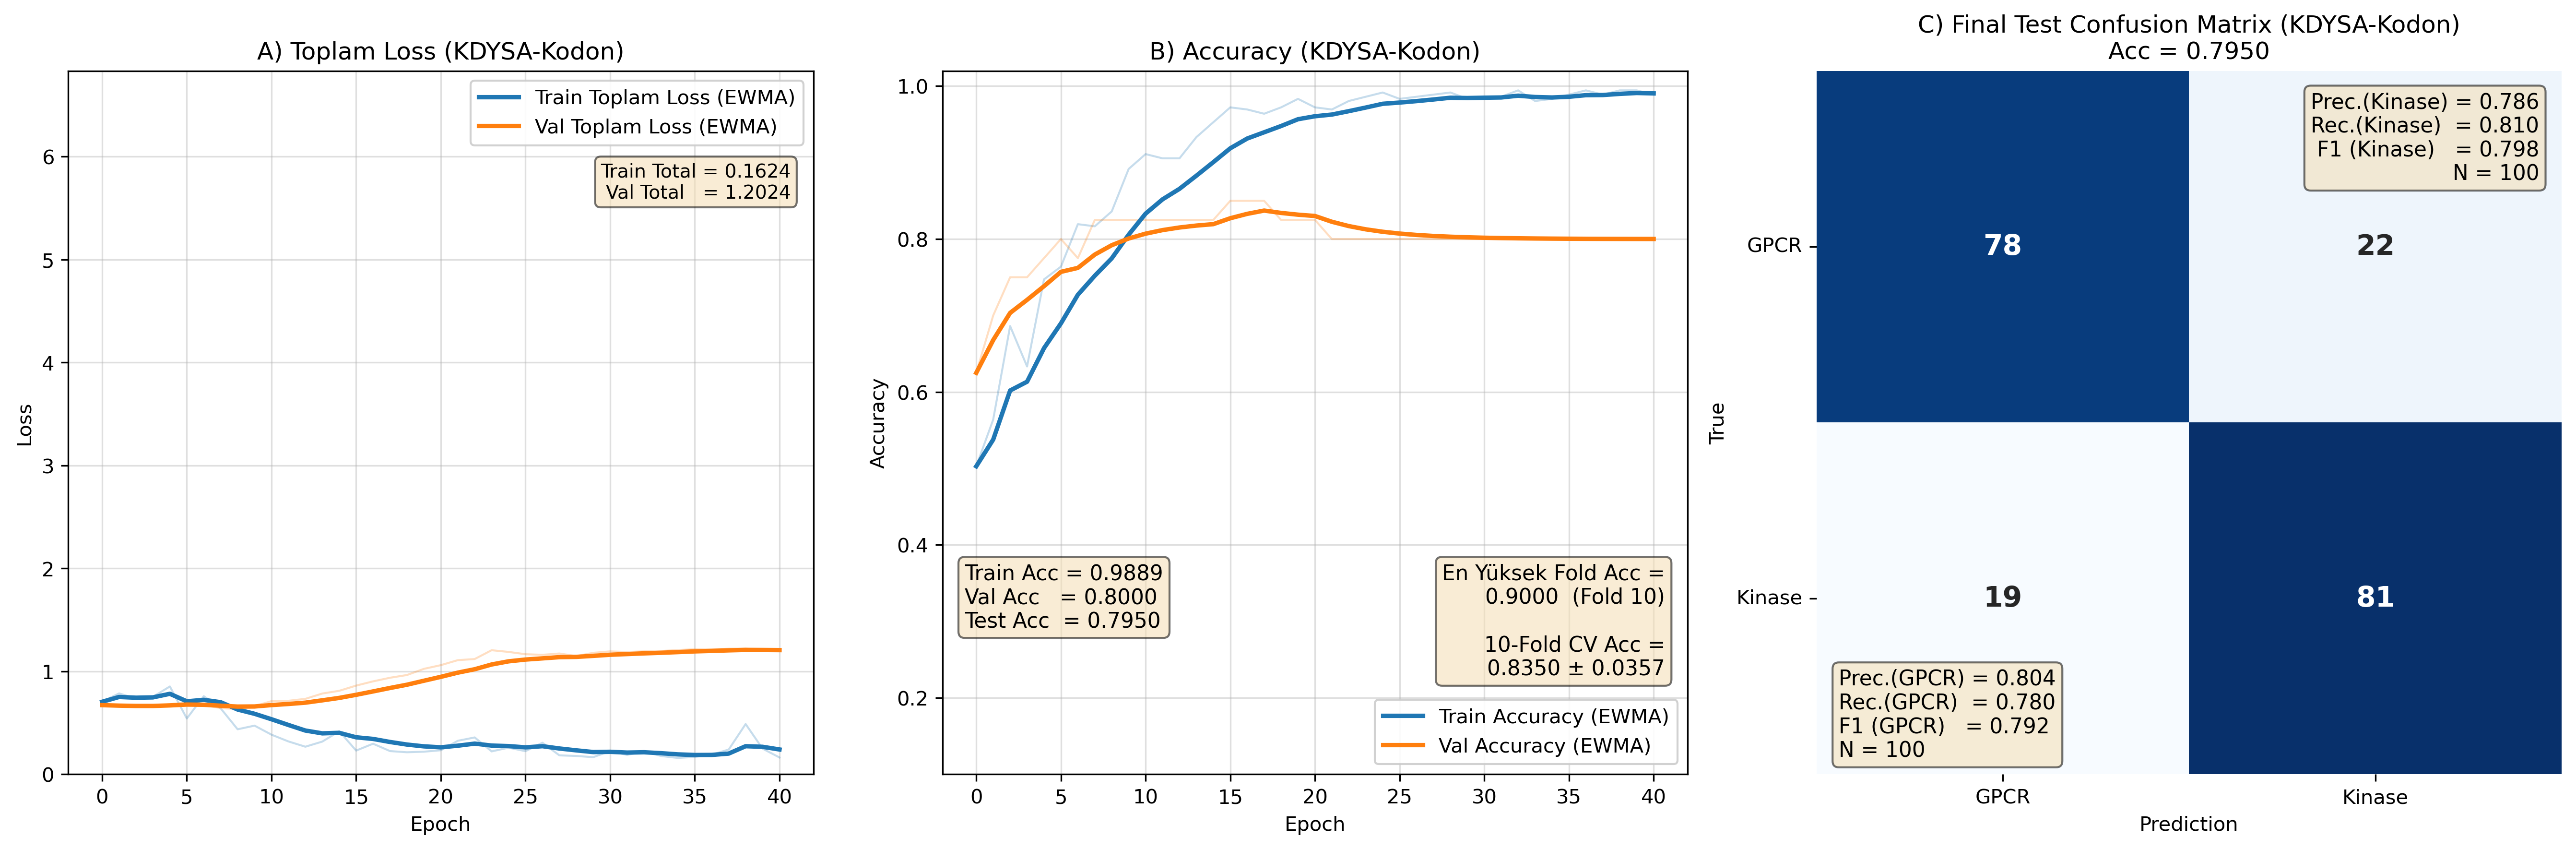

In [16]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME —  KDYSA KODON SINIFLANDIRMA
#
#   Panel A : Toplam Wirtinger Kayıp
#   Panel B : Accuracy (EWMA yumuşatmalı)
#   Panel C : Confusion Matrix
#
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, f1_score


# -------------------------------------------------------------------------
# 1.  History anahtarları
# -------------------------------------------------------------------------
LOSS_KEY       = "kayip"
VAL_LOSS_KEY   = "val_kayip"
CE_KEY         = "kayip_ce"
VAL_CE_KEY     = "val_kayip_ce"
CENTER_KEY     = "kayip_center"
VAL_CENTER_KEY = "val_kayip_center"
ACC_KEY        = "dogruluk"
VAL_ACC_KEY    = "val_dogruluk"


# -------------------------------------------------------------------------
# 2.  EWMA yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return pd.Series(np.asarray(dizi, dtype=float)) \
             .ewm(alpha=alpha, adjust=True).mean().values


h = final_history.history
train_loss_ham = np.asarray(h[LOSS_KEY],     dtype=float)
val_loss_ham   = np.asarray(h[VAL_LOSS_KEY], dtype=float)
train_acc_ham  = np.asarray(h[ACC_KEY],      dtype=float)
val_acc_ham    = np.asarray(h[VAL_ACC_KEY],  dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)


# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son = float(train_loss_ham[-1])
val_loss_son   = float(val_loss_ham[-1])
train_acc_son  = float(train_acc_ham[-1])
val_acc_son    = float(val_acc_ham[-1])

train_ce_son     = float(h[CE_KEY][-1])         if CE_KEY         in h else np.nan
val_ce_son       = float(h[VAL_CE_KEY][-1])     if VAL_CE_KEY     in h else np.nan
train_center_son = float(h[CENTER_KEY][-1])     if CENTER_KEY     in h else np.nan
val_center_son   = float(h[VAL_CENTER_KEY][-1]) if VAL_CENTER_KEY in h else np.nan


# -------------------------------------------------------------------------
# 4.  Test sınıf metrikleri
# -------------------------------------------------------------------------
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test_int, y_test_pred,
    labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_test_int, y_test_pred,
                         average="macro", zero_division=0)


# -------------------------------------------------------------------------
# 5.  CV özet
# -------------------------------------------------------------------------
cv_acc_mean           = cv_df["acc"].mean()
cv_acc_std            = cv_df["acc"].std(ddof=1)
cv_best_val_loss_mean = cv_df["best_val_loss"].mean()
cv_best_val_loss_std  = cv_df["best_val_loss"].std(ddof=1)
cv_best_val_acc_mean  = cv_df["best_val_acc"].mean()
cv_best_val_acc_std   = cv_df["best_val_acc"].std(ddof=1)
cv_macro_f1_mean      = cv_df["macro_f1"].mean()
cv_macro_f1_std       = cv_df["macro_f1"].std(ddof=1)
en_yuksek_fold_acc    = cv_df["acc"].max()
en_yuksek_fold_no     = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])



# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

# ── Panel A: sadece toplam loss + en yüksek fold loss ────────────────────
text_loss = "\n".join((
    f"Train Total = {train_loss_son:.4f}",
    f"Val Total   = {val_loss_son:.4f}",
))

# ── Panel B kutu 1: Train / Val / Test acc ────────────────────────────────
text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {test_acc:.4f}",
))

# ── Panel B kutu 2: fold istatistikleri ──────────────────────────────────
text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

# ── Panel C: sınıf kutuları  ──────────────────────────────────
text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))

text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))


# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN = "#1f77b4"
C_VAL   = "#ff7f0e"

# ==========================================================================
#  A) Toplam Wirtinger Kayıp
# ==========================================================================
ax[0].plot(train_loss_ham, color=C_TRAIN, linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[0].plot(val_loss_ham,   color=C_VAL,   linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[0].plot(train_loss_sm,  color=C_TRAIN, linewidth=2.2,
           label="Train Toplam Loss (EWMA)")
ax[0].plot(val_loss_sm,    color=C_VAL,   linewidth=2.2,
           label="Val Toplam Loss (EWMA)")

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9)
ax[0].set_title("A) Toplam Loss (KDYSA-Kodon)")

ymax_loss = max(np.max(train_loss_ham), np.max(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 5.60))

# Tek kutu: Train/Val Total + en düşük fold loss
ax[0].text(0.97, 0.87, text_loss,
           transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.5, bbox=props)

# ==========================================================================
#  B) Accuracy
# ==========================================================================
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2,
           label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2,
           label="Val Accuracy (EWMA)")

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title("B) Accuracy (KDYSA-Kodon)")
ax[1].set_ylim(0.1, 1.02)

# Kutu 1: Train / Val / Test Acc
ax[1].text(0.03, 0.30, text_acc_1,
           transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)

#    Kutu 2: fold istatistikleri
ax[1].text(0.97, 0.30, text_acc_2,
           transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

# ==========================================================================
#  C) Confusion Matrix
# ==========================================================================
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
            cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})

ax[2].set_xlabel("Prediction")
ax[2].set_ylabel("True")
ax[2].set_title(
    f"C) Final Test Confusion Matrix (KDYSA-Kodon)\nAcc = {test_acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]])
ax[2].set_yticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]], rotation=0)

ax[2].text(0.03, 0.15, text_gpcr,
           transform=ax[2].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase,
           transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

plt.tight_layout()
plt.savefig(f"wirtinger_hibrit_mlp_kodon_L{L}_gorsellestirme.png",
            dpi=600, bbox_inches="tight")
plt.show()

## 3) KDYSA ile kompleks değerli AMİNO ASİT dizisi sınıflandırma:
- Daha önce önerilen matematiksel yöntemlerle kompleks değerlere kodlanmış AMİNO ASİT dizilerine ait 400 train ve 200 test veri örneği kullanılarak kinaz (1) ve GPCR (0) protein aileleri KDYSA ile sınıflandırılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılır.
- Eğitim (train) ve Doğrulama (Val.) ve Son olarak Final Test için Accuracy oranları hesaplanmakta ve her iki sınıf için ayrı ayrı Precision/Recall/F1 hesaplanmaktadır.
- Sonuçlar grafiklerle görselleştirilir.

In [17]:
# =============================================================================
#  KOMPLEKS DEĞERLİ YAPAY SİNİR AĞLARI (KDYSA) - AMİNO ASİT SINIFLANDIRMA
#  L = 300     
#  
# =============================================================================
# GEREKLİ KÜTÜPHANELER
# =============================================================================
from __future__ import annotations

import json
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from tensorflow.keras import Model, layers
from tensorflow.keras.optimizers import Adam

# uyarı azaltma
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")


# =============================================================================
#    SABİTLER
# =============================================================================
# .npz dosyasının tam yolu (kendi makinene göre düzenle):
NPZ_YOLU          = r"C:\Users\matya\AA_Compleks_L300.npz"
CIKTI_DIZINI      = Path("./ciktilar_wirtinger_mlp_aa_L300_npz")
CIKTI_DIZINI.mkdir(exist_ok=True)

L                 = 300   
SINIF_SAYISI      = 2
SINIF_ADLARI      = {0: "GPCR", 1: "Kinase"}


GENLIK_NORMALIZASYONU = True

N_SPLITS          = 10
EPOCHS            = 200
BATCH_SIZE        = 10
OGRENME_ORANI     = 5e-4
WEIGHT_DECAY      = 1e-4

LAMBDA_CENTER_HEDEF     = 0.02
LAMBDA_CENTER_BASLANGIC = 0.0

LAMBDA_WARMUP_EPOCH     = 5

LABEL_SMOOTHING   = 0.02

NORON_SAYILARI    = (32, 16, 8)
DROPOUT_ORANLARI  = (0.30, 0.35, 0.35)


def yeni_run_seedi() -> int:
    return int(time.time() * 1000) % 10_000_000 + random.randint(0, 100_000)


RUN_SEED = yeni_run_seedi()
SPLIT_SEED = 42   
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)

print(f"[INFO] Ana run seed        : {RUN_SEED}")
print(f"[INFO] Çıktı dizini        : {CIKTI_DIZINI.resolve()}")
print(f"[INFO] Veri kaynağı        : {NPZ_YOLU}")
print(f"[INFO] L (kalıntı sayısı)  : {L}")
print(f"[INFO] Genlik norm. (X/L)  : {GENLIK_NORMALIZASYONU}")
print(f"[INFO] λ_center hedef      : {LAMBDA_CENTER_HEDEF} (warmup: {LAMBDA_WARMUP_EPOCH} epoch)")
print(f"[INFO] Dropout             : {DROPOUT_ORANLARI}")
print(f"[INFO] ReduceLR monitor    : val_kayip_ce")
print(f"[INFO] EarlyStop monitor   : val_dogruluk (max)")


# =============================================================================
#    KOMPLEKS AKTİVASYONLAR
# =============================================================================
def komplex_tanh(z: tf.Tensor) -> tf.Tensor:
    return tf.complex(tf.math.tanh(tf.math.real(z)),
                      tf.math.tanh(tf.math.imag(z)))


class ModReLU(layers.Layer):
    """f(z) = ReLU(|z| + b) · (z / |z|)"""
    def __init__(self, eps: float = 1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        self.b = self.add_weight(shape=(int(input_shape[-1]),),
                                 initializer="zeros", trainable=True, name="b")

    def call(self, z):
        genlik  = tf.abs(z)
        katsayi = tf.nn.relu(genlik + self.b) / (genlik + self.eps)
        return tf.cast(katsayi, z.dtype) * z


# =============================================================================
#     KOMPLEKS NORMALİZASYON & DROPOUT
# =============================================================================
class KarmasikKatmanNorm(layers.Layer):
    def __init__(self, eps=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.gamma = self.add_weight(shape=(2, d), initializer="ones",
                                     trainable=True, name="gamma")
        self.beta  = self.add_weight(shape=(2, d), initializer="zeros",
                                     trainable=True, name="beta")

    def call(self, z):
        zr, zi = tf.math.real(z), tf.math.imag(z)
        x = tf.stack([zr, zi], axis=1)
        ort = tf.reduce_mean(x, axis=[1, 2], keepdims=True)
        var = tf.reduce_mean(tf.square(x - ort), axis=[1, 2], keepdims=True)
        x_hat = (x - ort) / tf.sqrt(var + self.eps)
        x_hat = x_hat * self.gamma[None, ...] + self.beta[None, ...]
        return tf.complex(x_hat[:, 0, :], x_hat[:, 1, :])


class KarmasikDropout(layers.Layer):
    def __init__(self, oran=0.2, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.oran = float(oran)
        self.seed = int(seed)
        self.rng  = None

    def build(self, input_shape):
        self.rng = tf.random.Generator.from_seed(self.seed)

    def call(self, z, training=False):
        if (not training) or self.oran <= 0.0:
            return z
        tutma = 1.0 - self.oran
        sekil = tf.shape(tf.math.real(z))
        maske = self.rng.uniform(sekil, dtype=tf.float32)
        maske = tf.cast(maske < tutma, tf.float32) / tutma
        maske = tf.cast(maske, z.dtype)
        return z * maske


# =============================================================================
#     KOMPLEKS YOĞUN KATMAN:
# =============================================================================
class KarmasikYogun(layers.Layer):
    def __init__(self, noron_sayisi, aktivasyon=None, l2=0.0, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.noron_sayisi = int(noron_sayisi)
        self.aktivasyon   = aktivasyon
        self.l2           = float(l2)
        self.seed         = int(seed)

    def build(self, input_shape):
        d    = int(input_shape[-1])
        init = tf.keras.initializers.GlorotUniform(seed=self.seed)
        k    = 1.0 / np.sqrt(2.0)

        def si(shape, dtype=None):
            return tf.cast(init(shape, dtype=dtype), tf.float32) * k

        reg = tf.keras.regularizers.L2(self.l2) if self.l2 > 0 else None

        self.wr = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wr")
        self.wi = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wi")
        self.br = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="br")
        self.bi = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="bi")

    def call(self, x):
        xr, xi = tf.math.real(x), tf.math.imag(x)
        yr = tf.matmul(xr, self.wr) - tf.matmul(xi, self.wi) + self.br
        yi = tf.matmul(xr, self.wi) + tf.matmul(xi, self.wr) + self.bi
        y  = tf.complex(yr, yi)
        return self.aktivasyon(y) if self.aktivasyon is not None else y


# =============================================================================
#     PROTOTİP ENERJİ BAŞLIĞI
# =============================================================================
class PrototipEnerjiBasligi(layers.Layer):
    def __init__(self, sinif_sayisi=2, prototip_ogrenilsin=True,
                 stddev=0.05, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.sinif_sayisi        = int(sinif_sayisi)
        self.prototip_ogrenilsin = bool(prototip_ogrenilsin)
        self.stddev              = float(stddev)
        self.seed                = int(seed)

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.prototip_real = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=self.stddev, seed=self.seed),
            trainable=self.prototip_ogrenilsin, name="prototip_real")
        self.prototip_imaj = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(
                stddev=self.stddev, seed=self.seed + 1),
            trainable=self.prototip_ogrenilsin, name="prototip_imaj")

    def call(self, z):
        zr = tf.expand_dims(tf.math.real(z), axis=1)
        zi = tf.expand_dims(tf.math.imag(z), axis=1)
        pr = tf.expand_dims(self.prototip_real, axis=0)
        pi = tf.expand_dims(self.prototip_imaj, axis=0)
        enerji = tf.reduce_sum((zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
        return -enerji, enerji


# =============================================================================
#     WIRTINGER CE & WIRTINGER CENTER LOSS
# =============================================================================
def wirtinger_ce_kaybi(logit, y_onehot, label_smoothing=0.0):
    y = tf.cast(y_onehot, tf.float32)
    if label_smoothing > 0.0:
        C = tf.cast(tf.shape(y)[-1], tf.float32)
        y = y * (1.0 - label_smoothing) + label_smoothing / C
    log_p = tf.nn.log_softmax(logit, axis=-1)
    return -tf.reduce_mean(tf.reduce_sum(y * log_p, axis=-1))


def wirtinger_center_kaybi(z, y_onehot, proto_real, proto_imaj):
    y  = tf.cast(y_onehot, tf.float32)
    pr = tf.matmul(y, proto_real)
    pi = tf.matmul(y, proto_imaj)
    zr = tf.math.real(z)
    zi = tf.math.imag(z)
    kare_mesafe = tf.reduce_sum(
        (zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
    return 0.5 * tf.reduce_mean(kare_mesafe)


# =============================================================================
#     EĞİTİCİ MODEL
# =============================================================================
class KarmasikEgitici(Model):
    def __init__(self, kodlayici, baslik,
                 lambda_center_baslangic=0.0, label_smoothing=0.02):
        super().__init__()
        self.kodlayici       = kodlayici
        self.baslik          = baslik

        self.lambda_center   = tf.Variable(
            float(lambda_center_baslangic),
            trainable=False, dtype=tf.float32, name="lambda_center")

        self.label_smoothing = float(label_smoothing)
        self.acc             = tf.keras.metrics.CategoricalAccuracy(name="dogruluk")

    @property
    def metrics(self):
        return [self.acc]

    def call(self, x, training=False):
        z = self.kodlayici(x, training=training)
        logit, _ = self.baslik(z)
        return tf.nn.softmax(logit)

    def _kayip_hesapla(self, x_b, y_b, training=False):
        z = self.kodlayici(x_b, training=training)
        tf.debugging.assert_type(z, tf.complex64)
        logit, _ = self.baslik(z)
        prob = tf.nn.softmax(logit)

        kayip_ce = wirtinger_ce_kaybi(
            logit, y_b, label_smoothing=self.label_smoothing)

        kayip_center = wirtinger_center_kaybi(
            z, y_b,
            self.baslik.prototip_real,
            self.baslik.prototip_imaj)

        kayip_reg = tf.add_n(self.kodlayici.losses) \
                    if self.kodlayici.losses else 0.0

        toplam = kayip_ce + self.lambda_center * kayip_center + kayip_reg
        return toplam, kayip_ce, kayip_center, kayip_reg, prob

    def train_step(self, data):
        x_b, y_b = data
        with tf.GradientTape() as tape:
            toplam, kayip_ce, kayip_center, kayip_reg, prob = \
                self._kayip_hesapla(x_b, y_b, training=True)

        degiskenler = (self.kodlayici.trainable_variables
                       + self.baslik.trainable_variables)
        gradyanlar  = tape.gradient(toplam, degiskenler)
        gradyanlar  = [g if g is not None else tf.zeros_like(v)
                       for g, v in zip(gradyanlar, degiskenler)]
        gradyanlar, _ = tf.clip_by_global_norm(gradyanlar, 1.0)
        self.optimizer.apply_gradients(zip(gradyanlar, degiskenler))

        self.acc.update_state(y_b, prob)
        return {"kayip":         toplam,
                "kayip_ce":      kayip_ce,
                "kayip_center":  kayip_center,
                "kayip_reg":     kayip_reg,
                "lambda_center": self.lambda_center,
                "dogruluk":      self.acc.result()}

    def test_step(self, data):
        x_b, y_b = data
        toplam, kayip_ce, kayip_center, kayip_reg, prob = \
            self._kayip_hesapla(x_b, y_b, training=False)
        self.acc.update_state(y_b, prob)
        return {"kayip":         toplam,
                "kayip_ce":      kayip_ce,
                "kayip_center":  kayip_center,
                "kayip_reg":     kayip_reg,
                "lambda_center": self.lambda_center,
                "dogruluk":      self.acc.result()}


# =============================================================================
#     CALLBACKS
# =============================================================================
class PrototipIzleyiciCallback(tf.keras.callbacks.Callback):
    def __init__(self, kaydet_yolu: Path | None = None):
        super().__init__()
        self.tarih = []
        self.kaydet_yolu = kaydet_yolu

    def on_epoch_end(self, epoch, logs=None):
        pr = self.model.baslik.prototip_real.numpy()
        pi = self.model.baslik.prototip_imaj.numpy()
        ayrisma = float(np.sqrt(np.sum((pr[0] - pr[1]) ** 2
                                       + (pi[0] - pi[1]) ** 2)))
        self.tarih.append({"epoch": epoch, "p_ayrisma": ayrisma})
        if ayrisma < 1e-3:
            print(f"[UYARI] Epoch {epoch}: prototip ayrışması {ayrisma:.2e}")

    def on_train_end(self, logs=None):
        if self.kaydet_yolu is not None and len(self.tarih) > 0:
            pd.DataFrame(self.tarih).to_csv(self.kaydet_yolu, index=False)


# Lambda Center Scheduler
class LambdaCenterScheduler(tf.keras.callbacks.Callback):

    def __init__(self, baslangic=0.0, hedef=0.05, warmup_epoch=10, verbose=0):
        super().__init__()
        self.baslangic    = float(baslangic)
        self.hedef        = float(hedef)
        self.warmup_epoch = int(warmup_epoch)
        self.verbose      = int(verbose)

    def on_epoch_begin(self, epoch, logs=None):
        if self.warmup_epoch <= 0 or epoch >= self.warmup_epoch:
            yeni = self.hedef
        else:
            oran = epoch / self.warmup_epoch
            yeni = self.baslangic + (self.hedef - self.baslangic) * oran
        self.model.lambda_center.assign(yeni)
        if self.verbose:
            print(f"  [λ_center] Epoch {epoch}: {yeni:.4f}")


# =============================================================================
#     MODEL KURMA
# =============================================================================
def modeli_kur(L, seed,
               noronlar=NORON_SAYILARI,
               droplar=DROPOUT_ORANLARI,
               wd=WEIGHT_DECAY,
               lambda_baslangic=LAMBDA_CENTER_BASLANGIC,
               label_smoothing=LABEL_SMOOTHING,
               lr=OGRENME_ORANI) -> KarmasikEgitici:

    h1, h2, h3 = noronlar
    d1, d2, d3 = droplar

    giris = layers.Input(shape=(L,), dtype=tf.complex64, name="kompleks_giris")

    x = KarmasikYogun(h1, aktivasyon=None, l2=wd, seed=seed,
                      name="yogun_1")(giris)
    x = ModReLU(name="modrelu_1")(x)
    x = KarmasikKatmanNorm(name="norm_1")(x)
    x = KarmasikDropout(oran=d1, seed=seed, name="drop_1")(x)

    x = KarmasikYogun(h2, aktivasyon=komplex_tanh, l2=wd,
                      seed=seed + 1, name="yogun_2")(x)
    x = KarmasikKatmanNorm(name="norm_2")(x)
    x = KarmasikDropout(oran=d2, seed=seed + 1, name="drop_2")(x)

    z = KarmasikYogun(h3, aktivasyon=komplex_tanh, l2=wd,
                      seed=seed + 2, name="yogun_3")(x)
    z = KarmasikKatmanNorm(name="norm_3")(z)
    z = KarmasikDropout(oran=d3, seed=seed + 2, name="drop_3")(z)

    kodlayici = Model(giris, z, name="KarmasikMLPKodlayici")
    baslik    = PrototipEnerjiBasligi(sinif_sayisi=SINIF_SAYISI,
                                      seed=seed + 3, name="prototip_baslik")

    egitici = KarmasikEgitici(kodlayici=kodlayici, baslik=baslik,
                              lambda_center_baslangic=lambda_baslangic,
                              label_smoothing=label_smoothing)
    egitici.compile(optimizer=Adam(learning_rate=lr))
    egitici.build(input_shape=(None, L))
    return egitici


# =============================================================================
#    VERİ  —  .npz'den yükleme 
# =============================================================================
def veriyi_yukle_npz(npz_yolu, L, genlik_bol=True):

    d = np.load(npz_yolu, allow_pickle=False)

    def al(anahtar):
        if anahtar not in d.files:
            raise KeyError(
                f"'{anahtar}' anahtarı .npz içinde yok. "
                f"Mevcut anahtarlar: {list(d.files)}")
        return d[anahtar]

    X_tr = al("X_egitim").astype(np.complex64)
    X_te = al("X_test").astype(np.complex64)
    yi_tr = al("y_egitim").astype(int)
    yi_te = al("y_test").astype(int)

    # Şekil güvence kontrolü 
    assert X_tr.shape[1] == L, \
        f"Eğitim kalıntı sayısı {X_tr.shape[1]} != beklenen L={L}"
    assert X_te.shape[1] == L, \
        f"Test kalıntı sayısı {X_te.shape[1]} != beklenen L={L}"

    if genlik_bol:
        X_tr = (X_tr / np.complex64(L)).astype(np.complex64)
        X_te = (X_te / np.complex64(L)).astype(np.complex64)

    y_tr = tf.keras.utils.to_categorical(yi_tr, SINIF_SAYISI).astype(np.float32)
    y_te = tf.keras.utils.to_categorical(yi_te, SINIF_SAYISI).astype(np.float32)
    return X_tr, y_tr, yi_tr, X_te, y_te, yi_te


X_full_train, y_full_train, y_full_train_int, \
X_test,       y_test,       y_test_int = veriyi_yukle_npz(
    NPZ_YOLU, L=L, genlik_bol=GENLIK_NORMALIZASYONU)

print("\n" + "=" * 55)
print("  VERİ BİLGİSİ")
print("=" * 55)
print(f"CV havuzu   : {X_full_train.shape[0]} "
      f"(GPCR={np.sum(y_full_train_int == 0)}, "
      f"Kinase={np.sum(y_full_train_int == 1)})")
print(f"Final test  : {X_test.shape[0]} "
      f"(GPCR={np.sum(y_test_int == 0)}, "
      f"Kinase={np.sum(y_test_int == 1)})")
print(f"Girdi şekli : X_egitim {X_full_train.shape}  |  X_test {X_test.shape}")
print(f"|X| aralığı : [{np.abs(X_full_train).min():.4g}, "
      f"{np.abs(X_full_train).max():.4g}]  (genlik_bol={GENLIK_NORMALIZASYONU})")


# =============================================================================
#     CALLBACK   —  her fold için yenileniyor
# =============================================================================
def callback_listesi_olustur(kaydet_proto_csv: Path,
                             reduce_lr_monitor: str = "val_kayip_ce",   # [A3]
                             early_stop_monitor: str = "val_dogruluk",
                             early_stop_mode: str = "max",
                             reduce_lr_patience: int = 10,
                             early_stop_patience: int = 25,
                             reduce_verbose: int = 0,
                             early_verbose: int = 0):
    return [
        #  Early stopping val_dogruluk üzerinden, mode=max
        tf.keras.callbacks.EarlyStopping(
            monitor=early_stop_monitor, mode=early_stop_mode,
            patience=early_stop_patience,
            restore_best_weights=True, verbose=early_verbose),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=reduce_lr_monitor, factor=0.5,
            patience=reduce_lr_patience, min_lr=1e-5,
            verbose=reduce_verbose),
        tf.keras.callbacks.TerminateOnNaN(),
        #  λ_center warmup scheduler
        LambdaCenterScheduler(
            baslangic=LAMBDA_CENTER_BASLANGIC,
            hedef=LAMBDA_CENTER_HEDEF,
            warmup_epoch=LAMBDA_WARMUP_EPOCH,
            verbose=0),
        PrototipIzleyiciCallback(kaydet_yolu=kaydet_proto_csv),
    ]


# =============================================================================
#    10-FOLD CV
# =============================================================================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)

fold_sonuclari = []

for fold_no, (tr_idx, vl_idx) in enumerate(
        skf.split(X_full_train, y_full_train_int), start=1):

    print(f"\n{'=' * 48}\n  FOLD {fold_no}/{N_SPLITS}\n{'=' * 48}")

    fold_seed = RUN_SEED + fold_no * 100
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(fold_seed)
    np.random.seed(fold_seed)
    random.seed(fold_seed)

    X_tr, X_vl = X_full_train[tr_idx], X_full_train[vl_idx]
    y_tr, y_vl = y_full_train[tr_idx], y_full_train[vl_idx]
    y_vl_int   = y_full_train_int[vl_idx]

    model = modeli_kur(L=L, seed=fold_seed)

    callbacks = callback_listesi_olustur(
        kaydet_proto_csv=CIKTI_DIZINI / f"fold_{fold_no:02d}_prototip_izleme.csv")

    history = model.fit(X_tr, y_tr, validation_data=(X_vl, y_vl),
                        epochs=EPOCHS, batch_size=BATCH_SIZE,
                        callbacks=callbacks, verbose=0)

    np.savez_compressed(
        CIKTI_DIZINI / f"fold_{fold_no:02d}_history.npz",
        **{k: np.array(v) for k, v in history.history.items()})

    y_vl_pred = np.argmax(model.predict(X_vl, verbose=0), axis=1)
    fold_acc  = accuracy_score(y_vl_int, y_vl_pred)

    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, labels=[0, 1], average=None, zero_division=0)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, average="macro", zero_division=0)

    h = history.history
    best_val_loss   = float(np.nanmin(h["val_kayip"]))
    best_val_acc    = float(np.nanmax(h["val_dogruluk"]))
    best_val_ce     = float(np.nanmin(h["val_kayip_ce"]))
    best_val_center = float(np.nanmin(h["val_kayip_center"]))

    fold_sonuclari.append({
        "fold": fold_no, "acc": fold_acc, "macro_f1": macro_f1,
        "macro_precision": prec_cls.mean(), "macro_recall": rec_cls.mean(),
        "gpcr_precision": prec_cls[0], "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0], "gpcr_support": sup_cls[0],
        "kinase_precision": prec_cls[1], "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1], "kinase_support": sup_cls[1],
        "best_val_loss":   best_val_loss,
        "best_val_acc":    best_val_acc,
        "best_val_ce":     best_val_ce,
        "best_val_center": best_val_center,
        "epoch_sayisi":    len(h["kayip"]),
    })

    print(f"Fold Acc       : {fold_acc:.4f}  |  Macro F1     : {macro_f1:.4f}")
    print(f"GPCR F1        : {f1_cls[0]:.4f}  |  Kinase F1    : {f1_cls[1]:.4f}")
    print(f"Best Val Acc   : {best_val_acc:.4f}  |  Best Val CE : {best_val_ce:.4f}")
    print(f"Epoch sayısı   : {fold_sonuclari[-1]['epoch_sayisi']}")


cv_df = pd.DataFrame(fold_sonuclari)

print("\n" + "=" * 55)
print("  10-FOLD CV ÖZET  (Wirtinger Hibrit MLP, AA npz)")
print("=" * 55)
print(cv_df[["fold", "acc", "macro_f1", "gpcr_f1", "kinase_f1",
             "best_val_acc", "best_val_ce",
             "epoch_sayisi"]].round(4).to_string(index=False))

print("\n--- CV ORTALAMA ± STD ---")
for k in ["acc", "macro_f1", "gpcr_f1", "kinase_f1",
          "best_val_loss", "best_val_acc",
          "best_val_ce", "best_val_center", "epoch_sayisi"]:
    print(f"  {k:22s}: {cv_df[k].mean():.4f} ± {cv_df[k].std(ddof=1):.4f}")

cv_df.to_excel(CIKTI_DIZINI / "cv_10_fold_npz.xlsx", index=False)


# =============================================================================
#     FİNAL MODEL
# =============================================================================
print("\n" + "=" * 55)
print("  FİNAL MODEL EĞİTİMİ  (Wirtinger Hibrit MLP, AA npz)")
print("=" * 55)

final_seed   = RUN_SEED + 9999
median_epoch = int(np.median(cv_df["epoch_sayisi"]))
print(f"[INFO] CV medyan epoch : {median_epoch}")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(final_seed)
np.random.seed(final_seed)
random.seed(final_seed)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10,
                             random_state=final_seed)
(final_tr_idx, final_vl_idx), = sss.split(X_full_train, y_full_train_int)
X_ftr, X_fvl = X_full_train[final_tr_idx], X_full_train[final_vl_idx]
y_ftr, y_fvl = y_full_train[final_tr_idx], y_full_train[final_vl_idx]

print(f"[INFO] Final train : {len(final_tr_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_tr_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_tr_idx] == 1)})")
print(f"[INFO] Final val   : {len(final_vl_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_vl_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_vl_idx] == 1)})")

final_model = modeli_kur(L=L, seed=final_seed)

final_callbacks = callback_listesi_olustur(
    kaydet_proto_csv     = CIKTI_DIZINI / "final_prototip_izleme.csv",
    reduce_lr_patience   = 8,
    early_stop_patience  = 25,
    reduce_verbose       = 1,
    early_verbose        = 1,
)

for cb in final_callbacks:
    if isinstance(cb, LambdaCenterScheduler):
        cb.verbose = 1

final_history = final_model.fit(
    X_ftr, y_ftr, validation_data=(X_fvl, y_fvl),
    epochs=median_epoch + 50,
    batch_size=BATCH_SIZE,
    shuffle=True, callbacks=final_callbacks, verbose=1)

np.savez_compressed(CIKTI_DIZINI / "final_history.npz",
                    **{k: np.array(v) for k, v in final_history.history.items()})


# =============================================================================
#     TEST DEĞERLENDİRME
# =============================================================================
test_eval = final_model.evaluate(X_test, y_test, verbose=0, return_dict=True)
y_test_prob = final_model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

test_cm  = confusion_matrix(y_test_int, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test_int, y_test_pred)

prec_t, rec_t, f1_t, sup_t = precision_recall_fscore_support(
    y_test_int, y_test_pred, labels=[0, 1], average=None, zero_division=0)
_, _, macro_f1_t, _ = precision_recall_fscore_support(
    y_test_int, y_test_pred, average="macro", zero_division=0)

print("\n" + "=" * 55)
print("  FİNAL TEST  (Wirtinger Hibrit MLP, AA npz)")
print("=" * 55)
print(f"Confusion Matrix:")
print(f"              pred_GPCR   pred_Kinase")
print(f"  true_GPCR     {test_cm[0, 0]:5d}       {test_cm[0, 1]:5d}")
print(f"  true_Kinase   {test_cm[1, 0]:5d}       {test_cm[1, 1]:5d}")
print()
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Test Loss (toplam)  : {test_eval['kayip']:.4f}")
print(f"Test Wirtinger CE   : {test_eval['kayip_ce']:.4f}")
print(f"Test Wirtinger Cnt  : {test_eval['kayip_center']:.4f}")
print(f"Test Macro F1       : {macro_f1_t:.4f}")
print(f"GPCR   F1/P/R       : {f1_t[0]:.4f}/{prec_t[0]:.4f}/{rec_t[0]:.4f}  (N={sup_t[0]})")
print(f"Kinase F1/P/R       : {f1_t[1]:.4f}/{prec_t[1]:.4f}/{rec_t[1]:.4f}  (N={sup_t[1]})")


# =============================================================================
#     KAYITLAR
# =============================================================================
final_model.save_weights(CIKTI_DIZINI / "final_model.weights.h5")

pd.DataFrame({
    "idx":          np.arange(len(y_test_int)),
    "y_true":       y_test_int,
    "y_true_label": [SINIF_ADLARI[i] for i in y_test_int],
    "y_pred":       y_test_pred,
    "y_pred_label": [SINIF_ADLARI[i] for i in y_test_pred],
    "prob_GPCR":    y_test_prob[:, 0],
    "prob_Kinase":  y_test_prob[:, 1],
}).to_csv(CIKTI_DIZINI / "test_tahminleri.csv", index=False)

meta = {
    "mimari":              "kompleks_mlp_wirtinger_hibrit_aa_npz",
    "veri_kaynagi":        str(NPZ_YOLU),
    "temsil":              "amino asit (300 kalıntı)",
    "genlik_normalizasyonu": (f"X / L (L={L})" if GENLIK_NORMALIZASYONU
                              else "yok (ilk katman batch-norm bekleniyor)"),
    "L":                   L,
    "kayip_formulasyonu":  "L = L_CE_wirtinger + lambda(t)*L_center_wirtinger + L2",
    "ayarlar":             {
        "lambda_hedef":      LAMBDA_CENTER_HEDEF,
        "warmup_epoch":      LAMBDA_WARMUP_EPOCH,
        "reduce_lr_monitor": "val_kayip_ce",
        "early_stop":        "val_dogruluk (mode=max)",
        "final_patience":    25,
        "dropout":           list(DROPOUT_ORANLARI),
        "scheduler":         "LambdaCenterScheduler (lineer warmup)",
    },
    "lambda_center_baslangic": LAMBDA_CENTER_BASLANGIC,
    "lambda_center_hedef":     LAMBDA_CENTER_HEDEF,
    "label_smoothing":         LABEL_SMOOTHING,
    "weight_decay":            WEIGHT_DECAY,
    "run_seed":                RUN_SEED,
    "final_seed":              final_seed,
    "n_splits":                N_SPLITS,
    "epochs_limit":            EPOCHS,
    "batch_size":              BATCH_SIZE,
    "lr":                      OGRENME_ORANI,
    "noron_sayilari":          list(NORON_SAYILARI),
    "cv_medyan_epoch":         int(median_epoch),
    "cv_acc_ortalama":         float(cv_df["acc"].mean()),
    "cv_acc_std":              float(cv_df["acc"].std(ddof=1)),
    "cv_macro_f1_ort":         float(cv_df["macro_f1"].mean()),
    "cv_macro_f1_std":         float(cv_df["macro_f1"].std(ddof=1)),
    "test_acc":                float(test_acc),
    "test_macro_f1":           float(macro_f1_t),
    "test_loss":               float(test_eval["kayip"]),
    "test_loss_ce":            float(test_eval["kayip_ce"]),
    "test_loss_center":        float(test_eval["kayip_center"]),
    "tensorflow":              tf.__version__,
    "numpy":                   np.__version__,
}
with open(CIKTI_DIZINI / "deney_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print(f"\n[INFO] Tüm kayıtlar: {CIKTI_DIZINI.resolve()}")

[INFO] Ana run seed        : 4393165
[INFO] Çıktı dizini        : C:\Users\matya\ciktilar_wirtinger_mlp_aa_L300_npz
[INFO] Veri kaynağı        : C:\Users\matya\AA_Compleks_L300.npz
[INFO] L (kalıntı sayısı)  : 300
[INFO] Genlik norm. (X/L)  : True
[INFO] λ_center hedef      : 0.02 (warmup: 5 epoch)
[INFO] Dropout             : (0.3, 0.35, 0.35)
[INFO] ReduceLR monitor    : val_kayip_ce
[INFO] EarlyStop monitor   : val_dogruluk (max)

  VERİ BİLGİSİ
CV havuzu   : 400 (GPCR=200, Kinase=200)
Final test  : 200 (GPCR=100, Kinase=100)
Girdi şekli : X_egitim (400, 300)  |  X_test (200, 300)
|X| aralığı : [0.003333, 1]  (genlik_bol=True)

  FOLD 1/10
Fold Acc       : 0.8000  |  Macro F1     : 0.7995
GPCR F1        : 0.8095  |  Kinase F1    : 0.7895
Best Val Acc   : 0.8000  |  Best Val CE : 0.3990
Epoch sayısı   : 38

  FOLD 2/10
Fold Acc       : 0.8750  |  Macro F1     : 0.8730
GPCR F1        : 0.8571  |  Kinase F1    : 0.8889
Best Val Acc   : 0.8750  |  Best Val CE : 0.2004
Epoch sayısı   : 5

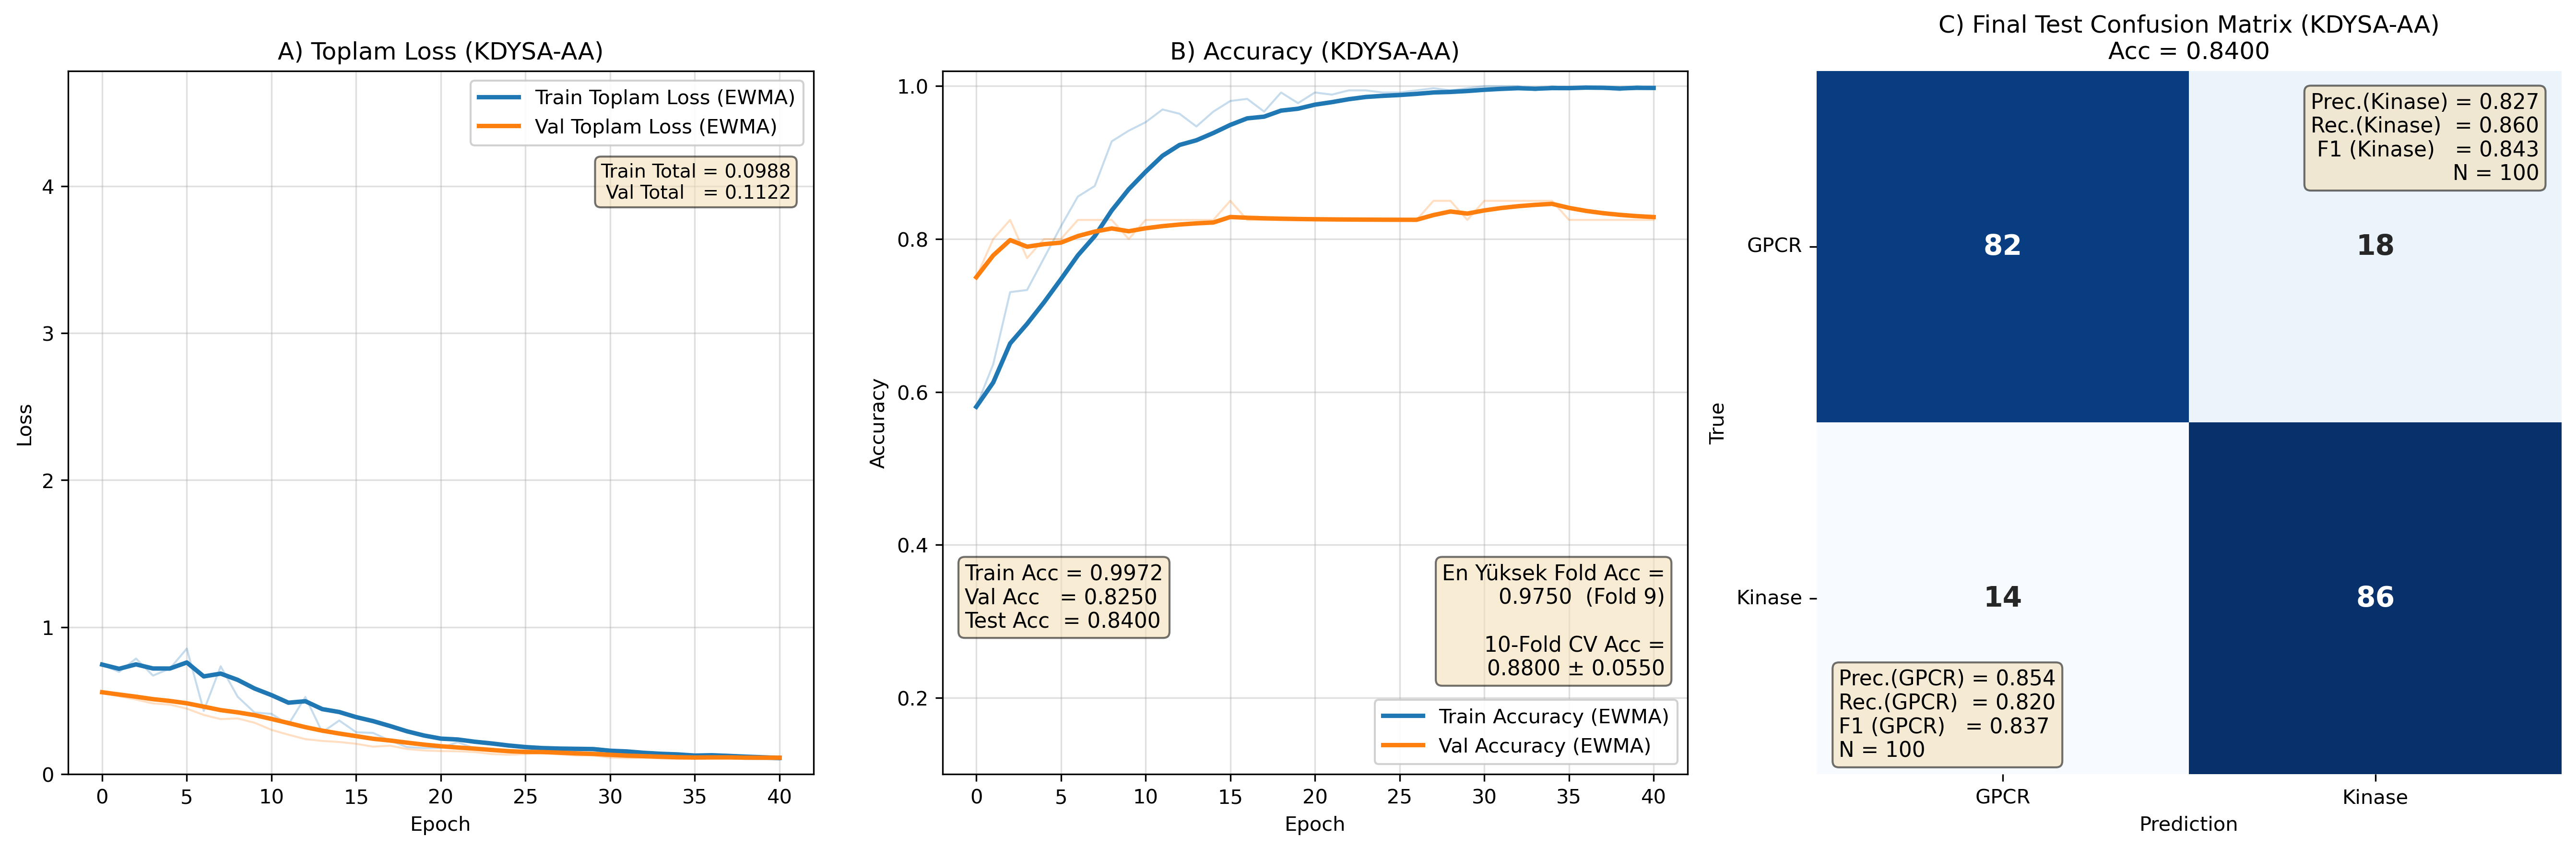

In [18]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME —  KDYSA AA SINIFLANDIRMA
#
#   Panel A : Toplam Wirtinger Kayıp
#   Panel B : Accuracy (EWMA yumuşatmalı)
#   Panel C : Confusion Matrix
#
#   
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, f1_score


# -------------------------------------------------------------------------
# 1.  History anahtarları
# -------------------------------------------------------------------------
LOSS_KEY       = "kayip"
VAL_LOSS_KEY   = "val_kayip"
CE_KEY         = "kayip_ce"
VAL_CE_KEY     = "val_kayip_ce"
CENTER_KEY     = "kayip_center"
VAL_CENTER_KEY = "val_kayip_center"
ACC_KEY        = "dogruluk"
VAL_ACC_KEY    = "val_dogruluk"


# -------------------------------------------------------------------------
# 2.  EWMA yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return pd.Series(np.asarray(dizi, dtype=float)) \
             .ewm(alpha=alpha, adjust=True).mean().values


h = final_history.history
train_loss_ham = np.asarray(h[LOSS_KEY],     dtype=float)
val_loss_ham   = np.asarray(h[VAL_LOSS_KEY], dtype=float)
train_acc_ham  = np.asarray(h[ACC_KEY],      dtype=float)
val_acc_ham    = np.asarray(h[VAL_ACC_KEY],  dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)


# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son = float(train_loss_ham[-1])
val_loss_son   = float(val_loss_ham[-1])
train_acc_son  = float(train_acc_ham[-1])
val_acc_son    = float(val_acc_ham[-1])

train_ce_son     = float(h[CE_KEY][-1])         if CE_KEY         in h else np.nan
val_ce_son       = float(h[VAL_CE_KEY][-1])     if VAL_CE_KEY     in h else np.nan
train_center_son = float(h[CENTER_KEY][-1])     if CENTER_KEY     in h else np.nan
val_center_son   = float(h[VAL_CENTER_KEY][-1]) if VAL_CENTER_KEY in h else np.nan


# -------------------------------------------------------------------------
# 4.  Test sınıf metrikleri
# -------------------------------------------------------------------------
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test_int, y_test_pred,
    labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_test_int, y_test_pred,
                         average="macro", zero_division=0)


# -------------------------------------------------------------------------
# 5.  CV özet
# -------------------------------------------------------------------------
cv_acc_mean           = cv_df["acc"].mean()
cv_acc_std            = cv_df["acc"].std(ddof=1)
cv_best_val_loss_mean = cv_df["best_val_loss"].mean()
cv_best_val_loss_std  = cv_df["best_val_loss"].std(ddof=1)
cv_best_val_acc_mean  = cv_df["best_val_acc"].mean()
cv_best_val_acc_std   = cv_df["best_val_acc"].std(ddof=1)
cv_macro_f1_mean      = cv_df["macro_f1"].mean()
cv_macro_f1_std       = cv_df["macro_f1"].std(ddof=1)
en_yuksek_fold_acc    = cv_df["acc"].max()
en_yuksek_fold_no     = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])



# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

# ── Panel A: sadece toplam loss + en yüksek fold loss ────────────────────
text_loss = "\n".join((
    f"Train Total = {train_loss_son:.4f}",
    f"Val Total   = {val_loss_son:.4f}",
))

# ── Panel B kutu 1: Train / Val / Test acc ────────────────────────────────
text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {test_acc:.4f}",
))

# ── Panel B kutu 2: fold istatistikleri ──────────────────────────────────
text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

# ── Panel C: sınıf kutuları  ──────────────────────────────────
text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))

text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))


# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN = "#1f77b4"
C_VAL   = "#ff7f0e"

# ==========================================================================
#  A) Toplam Wirtinger Kayıp
# ==========================================================================
ax[0].plot(train_loss_ham, color=C_TRAIN, linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[0].plot(val_loss_ham,   color=C_VAL,   linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[0].plot(train_loss_sm,  color=C_TRAIN, linewidth=2.2,
           label="Train Toplam Loss (EWMA)")
ax[0].plot(val_loss_sm,    color=C_VAL,   linewidth=2.2,
           label="Val Toplam Loss (EWMA)")

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9)
ax[0].set_title("A) Toplam Loss (KDYSA-AA)")

ymax_loss = max(np.max(train_loss_ham), np.max(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 5.60))

# Tek kutu: Train/Val Total + en düşük fold loss
ax[0].text(0.97, 0.87, text_loss,
           transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.5, bbox=props)

# ==========================================================================
#  B) Accuracy
# ==========================================================================
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0,
           alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2,
           label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2,
           label="Val Accuracy (EWMA)")

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title("B) Accuracy (KDYSA-AA)")
ax[1].set_ylim(0.1, 1.02)

# Kutu 1: Train / Val / Test Acc
ax[1].text(0.03, 0.30, text_acc_1,
           transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)

#    Kutu 2: fold istatistikleri
ax[1].text(0.97, 0.30, text_acc_2,
           transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

# ==========================================================================
#  C) Confusion Matrix
# ==========================================================================
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
            cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})

ax[2].set_xlabel("Prediction")
ax[2].set_ylabel("True")
ax[2].set_title(
    f"C) Final Test Confusion Matrix (KDYSA-AA)\nAcc = {test_acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]])
ax[2].set_yticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]], rotation=0)

ax[2].text(0.03, 0.15, text_gpcr,
           transform=ax[2].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase,
           transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

plt.tight_layout()
plt.savefig(f"wirtinger_hibrit_mlp_AA_L{L}_gorsellestirme.png",
            dpi=600, bbox_inches="tight")
plt.show()